# RF-dressed NV–$^{14}$N tripod with QuaCCAToo

This notebook implements the construction described on the first two pages of the supplied paper. The three $m_I=-1,0,+1$ states in the $m_s=0$ manifold are the tripod ground states. RF fields dress the corresponding $m_s=-1$ manifold; its lowest rotating-frame eigenstate is selected as

$$|e\rangle=c_-|-1,-1\rangle+c_0|-1,0\rangle+c_+|-1,+1\rangle.$$

Three phase-coherent microwave tones then connect $|e\rangle$ to $|g_-\rangle=|0,-1\rangle$, $|g_0\rangle=|0,0\rangle$, and $|g_+\rangle=|0,+1\rangle$.

**Modeling boundary.** QuaCCAToo supplies the physical nine-level NV–$^{14}$N Hamiltonian, its RF/MW operators, and transition metadata. The paper does not uniquely specify the experimental RF polarization, two-tone calibration, detunings, or pulse shapes on its first two pages. The rotating-frame RF matrix below is therefore an explicit, editable assumption. The example values are illustrative, not a fit to the paper.

## Notebook map

The notebook is organized as a sequence of physical reductions:

1. **Bare NV–$^{14}$N system:** construct the full nine-level QuaCCAToo model and identify the two three-state hyperfine manifolds.
2. **RF dressing:** diagonalize an explicit rotating-frame RF Hamiltonian and select a spectrally isolated dressed ancilla.
3. **Effective tripod:** project three microwave transitions onto that ancilla and verify Equations (3)–(6) of the paper.
4. **Non-Abelian holonomy:** implement the phase loops of Equations (7)–(10) with QuaCCAToo `PulsedSim` and perform the order-swap test.
5. **Control visualization:** display representative RF and microwave envelopes.

Each figure is followed by a short explanation of how it was generated and what its features mean physically.


In [1]:
# Numerical arrays and plotting.
import numpy as np
import matplotlib.pyplot as plt
# QuTiP supplies the state/operator representation used internally by QuaCCAToo.
from qutip import basis, Qobj, tensor, expect, qeye
# QuaCCAToo provides the NV model, quantum systems, pulse sequences, and pulse shapes.
from quaccatoo import NV, QSys, PulsedSim, gaussian_pulse

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120})
np.set_printoptions(precision=5, suppress=True)

# ---- Editable physical/model parameters ----
B0_mT = 20.0                  # axial field used by QuaCCAToo NV model
rf_detuning_MHz = np.array([0.16, -0.07, 0.11])
rf_Omega_MHz = np.array([0.80, 0.68])       # (-1)<->0 and 0<->(+1)
rf_phase_rad = np.array([0.00, 0.35])
mw_Omega_MHz = np.array([0.24, 0.20, 0.22])
mw_phase_rad = np.array([0.00, 2*np.pi/3, -2*np.pi/3])
mw_detuning_MHz = np.zeros(3)

# Timing in microseconds
t_end, rf_on, rf_off, edge_sigma = 8.0, 0.7, 7.3, 0.18
mw_centers, mw_sigma = np.array([3.35, 4.00, 4.65]), 0.72

# Build the complete 3 electron levels x 3 nuclear levels NV-14N model.
nv = NV(B0=B0_mT, units_B0='mT', N=14)
print('QuaCCAToo NV Hilbert-space dimension:', nv.H0.shape[0])
print('QuaCCAToo RF transition frequencies (MHz):', nv.RF_freqs)
print('QuaCCAToo MW manifold frequencies (MHz):', nv.MW_freqs)

QuaCCAToo NV Hilbert-space dimension: 9
QuaCCAToo RF transition frequencies (MHz): [4.94632 5.06837 7.09161 2.93153 2.80846 7.21366]
QuaCCAToo MW manifold frequencies (MHz): [2309.5066  3430.50396]


## 1. Bare NV–$^{14}$N hyperfine manifolds

### Section overview

This section builds the complete $3\times3=9$ dimensional electron–nuclear system with QuaCCAToo, labels the product states, and extracts the bare $m_s=0$ and $m_s=-1$ energies used by the later RF and microwave models.

QuaCCAToo constructs

$$H_0=D S_z^2+H_{eZ}+H_{nZ}+H_{\rm hf}+H_Q$$

for the full electron-spin-1 ⊗ nuclear-spin-1 space. With the field along the NV axis, product states remain a transparent labeling basis. QuTiP orders spin-1 states as $m=+1,0,-1$, so the helper below reverses the nuclear index to display $m_I=-1,0,+1$. Energies are shifted by the lowest $m_s=0$ energy for readability.

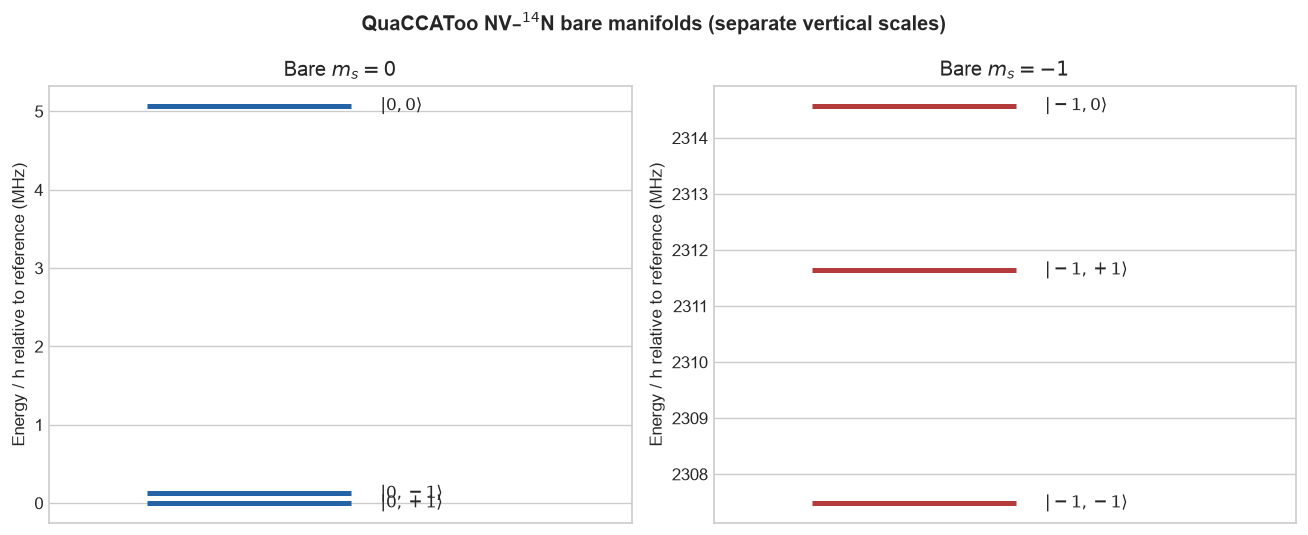

m_s=0 energies (MHz): [0.12308 5.07154 0.     ]
m_s=-1 energies (MHz): [2307.48405 2314.57251 2311.64097]


In [2]:
# Map physical spin labels onto QuTiP's descending spin-1 basis ordering.
def ket(ms, mi):
    """Build one NV–14N product ket.

    Parameters
    ----------
    ms : int
        Electron spin projection; expected values are -1, 0, or +1.
    mi : int
        Nitrogen-14 nuclear spin projection; expected values are -1, 0, or +1.

    Returns
    -------
    qutip.Qobj
        A normalized nine-component ket |ms,mi>. Physically, it labels one
        bare electron–nuclear hyperfine state in the full QuaCCAToo model.
    """
    idx = {+1: 0, 0: 1, -1: 2}
    return tensor(basis(3, idx[ms]), basis(3, idx[mi]))

mI_order = [-1, 0, +1]
states_0 = [ket(0, mi) for mi in mI_order]
states_m1 = [ket(-1, mi) for mi in mI_order]

def expectation_energy(state):
    """Evaluate the bare energy of a supplied NV–14N state.

    Parameters
    ----------
    state : qutip.Qobj
        Normalized ket in the same nine-dimensional Hilbert space as nv.H0.

    Returns
    -------
    float
        Expectation value <state|H0|state> in MHz. This is the physical bare
        transition-energy coordinate used in the manifold diagram.
    """
    return float(np.real((state.dag() * nv.H0 * state)))

# Evaluate the full QuaCCAToo Hamiltonian in each labeled product state.
E0 = np.array([expectation_energy(s) for s in states_0])
Em1 = np.array([expectation_energy(s) for s in states_m1])
reference = E0.min()
E0, Em1 = E0-reference, Em1-reference

def draw_levels(ax, energies, labels, color):
    """Draw a compact energy-level diagram on a Matplotlib axis.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis on which the horizontal energy levels will be drawn.
    energies : array-like of float
        Energy or quasienergy coordinates in MHz.
    labels : sequence of str
        State labels paired one-to-one with `energies`.
    color : str
        Matplotlib color used for the level lines.

    Returns
    -------
    None
        The supplied axis is modified in place. Physically, the line heights
        display the relative energies of the labeled quantum states.
    """
    for y, label in zip(energies, labels):
        ax.hlines(y, -0.28, 0.28, color=color, lw=3)
        ax.text(0.36, y, label, va='center')
    ax.set_xlim(-0.55, 1.05); ax.set_xticks([])

# Use separate vertical scales because the electron splitting is much larger than nuclear splittings.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
draw_levels(axes[0], E0, [r'$|0,-1\rangle$',r'$|0,0\rangle$',r'$|0,+1\rangle$'], '#2463a6')
draw_levels(axes[1], Em1, [r'$|-1,-1\rangle$',r'$|-1,0\rangle$',r'$|-1,+1\rangle$'], '#b33b3b')
axes[0].set(title=r'Bare $m_s=0$', ylabel='Energy / h relative to reference (MHz)')
axes[1].set(title=r'Bare $m_s=-1$', ylabel='Energy / h relative to reference (MHz)')
fig.suptitle(r'QuaCCAToo NV–$^{14}$N bare manifolds (separate vertical scales)', fontweight='bold')
fig.tight_layout(); plt.show()

print('m_s=0 energies (MHz):', E0)
print('m_s=-1 energies (MHz):', Em1)

#### Reading the bare-manifold figure

**How it was generated.** Each horizontal line is the expectation value $\langle m_s,m_I|H_0|m_s,m_I\rangle$ of QuaCCAToo's full nine-level NV–$^{14}$N Hamiltonian. The minimum $m_s=0$ energy is subtracted as a common reference, and separate vertical scales are used because the electronic splitting is much larger than the nuclear hyperfine splittings.

**Physical intuition.** The three lines in each panel are the resolved $m_I=-1,0,+1$ hyperfine states. Microwave fields connect the two panels while approximately preserving $m_I$; RF fields act within a panel by changing $m_I$ by one unit.

## 2. RF dressing and ancilla selection

### Section overview

This section introduces the editable RF rotating-frame model, diagonalizes it, selects the lowest-quasienergy eigenstate as $|e\rangle$, and visualizes both its energy isolation and bare-state composition.

In the rotating frame and ordered basis $\{|-1,-1\rangle,|-1,0\rangle,|-1,+1\rangle\}$, assume

$$\frac{H_{\rm RF}}{h}=\begin{pmatrix}
\delta_-&\Omega_{-0}e^{-i\phi_{-0}}/2&0\\
\Omega_{-0}e^{i\phi_{-0}}/2&\delta_0&\Omega_{0+}e^{-i\phi_{0+}}/2\\
0&\Omega_{0+}e^{i\phi_{0+}}/2&\delta_+
\end{pmatrix}.$$

The nearest-neighbor structure matches the $\Delta m_I=\pm1$ selection rule represented by `nv.RF_Rx` and `nv.RF_Ry`. The numerical Rabi rates and detunings are assumptions because they are not fixed by the paper. We wrap this matrix in a QuaCCAToo `QSys`, diagonalize it, and choose the lowest rotating-frame quasienergy as $|e\rangle$.

In [3]:
# Convert the two RF Rabi rates and phases into complex half-couplings.
v_m0 = 0.5*rf_Omega_MHz[0]*np.exp(-1j*rf_phase_rad[0])
v_0p = 0.5*rf_Omega_MHz[1]*np.exp(-1j*rf_phase_rad[1])
H_rf_array = np.array([[rf_detuning_MHz[0], v_m0, 0],
                       [np.conj(v_m0), rf_detuning_MHz[1], v_0p],
                       [0, np.conj(v_0p), rf_detuning_MHz[2]]], complex)
# Wrap the rotating-frame RF Hamiltonian in QuaCCAToo for consistent units and system metadata.
rf_system = QSys(H0=Qobj(H_rf_array), rho0=basis(3, 0), observable=Qobj(np.eye(3)), units_H0='MHz')

# Diagonalize and identify the lowest rotating-frame dressed eigenstate.
evals, evecs = np.linalg.eigh(H_rf_array)
e_index = int(np.argmin(evals))
c = evecs[:, e_index]
c *= np.exp(-1j*np.angle(c[np.argmax(np.abs(c))]))  # choose a convenient global phase
Delta_RF = evals[1]-evals[0]

print('H_RF / h (MHz):\n', H_rf_array)
print('\nDressed quasienergies (MHz):', evals)
print('[c_-, c_0, c_+] =', c)
print('|c_j|^2 =', np.abs(c)**2, '; sum =', np.sum(np.abs(c)**2))
print('Isolation gap Δ_RF =', Delta_RF, 'MHz')
assert np.isclose(np.sum(np.abs(c)**2), 1)
assert np.allclose(H_rf_array, H_rf_array.conj().T)


H_RF / h (MHz):
 [[ 0.16   +0.j       0.4    +0.j       0.     +0.j     ]
 [ 0.4    -0.j      -0.07   +0.j       0.31939-0.11659j]
 [ 0.     +0.j       0.31939+0.11659j  0.11   +0.j     ]]

Dressed quasienergies (MHz): [-0.50115  0.13053  0.57062]
[c_-, c_0, c_+] = [-0.46739-0.j       0.77255+0.j      -0.40373-0.14737j]
|c_j|^2 = [0.21846 0.59683 0.18472] ; sum = 0.9999999999999998
Isolation gap Δ_RF = 0.6316846745374287 MHz


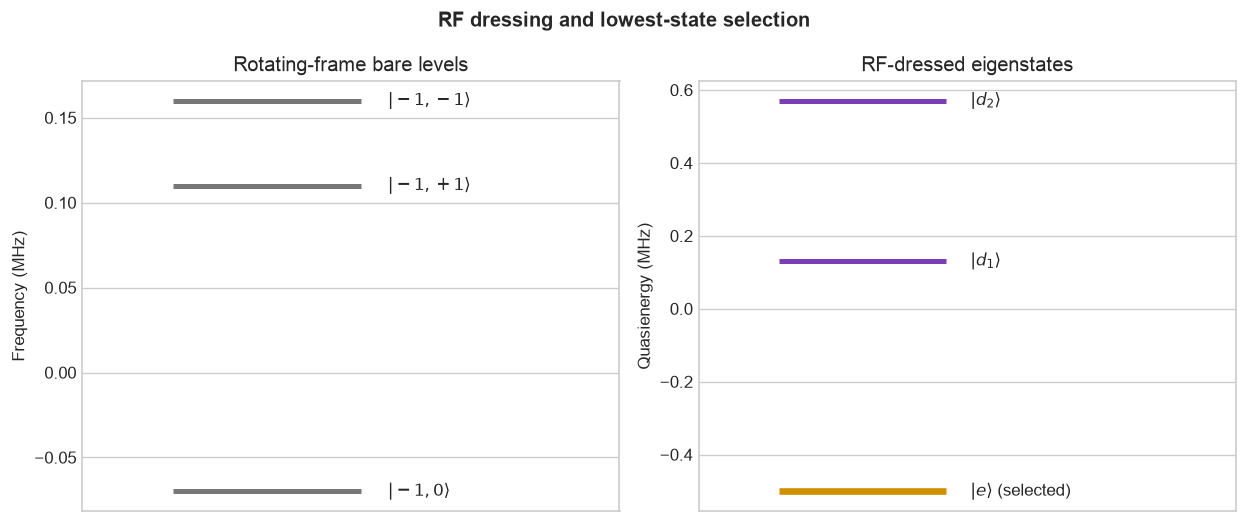

In [4]:
# Compare the assumed rotating-frame bare levels with their dressed quasienergies.
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
draw_levels(axes[0], rf_detuning_MHz, [r'$|-1,-1\rangle$',r'$|-1,0\rangle$',r'$|-1,+1\rangle$'], '#777777')
axes[0].set(title='Rotating-frame bare levels', ylabel='Frequency (MHz)')
for i, y in enumerate(evals):
    selected = i == e_index
    axes[1].hlines(y, -0.28, 0.28, color='#d29000' if selected else '#7a3db8', lw=4 if selected else 3)
    axes[1].text(0.36, y, r'$|e\rangle$ (selected)' if selected else rf'$|d_{i}\rangle$', va='center')
axes[1].set(xlim=(-0.55,1.25), xticks=[], title='RF-dressed eigenstates', ylabel='Quasienergy (MHz)')
fig.suptitle('RF dressing and lowest-state selection', fontweight='bold')
fig.tight_layout(); plt.show()


#### Reading the RF-dressed energy diagram

**How it was generated.** The left panel plots the three diagonal detunings of `H_rf_array`. The right panel plots its numerical eigenvalues. The orange line marks the eigenstate with the lowest rotating-frame quasienergy, which the notebook labels $|e\rangle$.

**Physical intuition.** RF coupling hybridizes the three bare $m_s=-1$ nuclear states and opens quasienergy gaps. The nearest gap, $\Delta_{\rm RF}$, controls how well the selected ancilla can be addressed without populating the other dressed eigenstates.

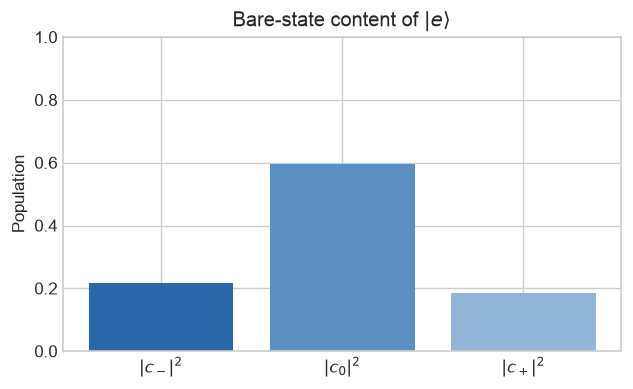

In [5]:
plt.figure(figsize=(6,3.4))
plt.bar([r'$|c_-|^2$',r'$|c_0|^2$',r'$|c_+|^2$'], np.abs(c)**2, color=['#2868a8','#5b8fc2','#91b5d7'])
plt.ylim(0,1); plt.ylabel('Population'); plt.title(r'Bare-state content of $|e\rangle$'); plt.show()

#### Reading the dressed-state composition

**How it was generated.** The bar heights are $|c_-|^2$, $|c_0|^2$, and $|c_+|^2$ from the normalized lowest eigenvector of `H_rf_array`.

**Physical intuition.** These values are the probabilities of finding the selected ancilla in each bare $|-1,m_I\rangle$ component. They also determine the strengths of the three projected microwave legs: a small $|c_m|$ weakens the corresponding effective tripod coupling.

## 3. Effective phase-coherent microwave tripod

### Section overview

This section projects the three nuclear-spin-preserving microwave transitions onto the selected RF-dressed ancilla. It then verifies the resulting four-state Hamiltonian, bright state, and dark-state basis directly against Equations (3)–(6) of the paper.

Page 2's four-state rotating-wave Hamiltonian is

$$\frac{H_{\rm tripod}(t)}{h}=\sum_{j\in\{-,0,+\}}\left[\Delta_j|g_j\rangle\langle g_j|+\frac{\widetilde\Omega_j(t)}{2}|e\rangle\langle g_j|+\mathrm{h.c.}\right].$$

For a nuclear-spin-preserving microwave operator, projection onto the dressed state yields $\widetilde\Omega_j=c_j^*\Omega_j e^{-i\phi_j}$. Therefore $c_-,c_0,c_+$ are complex probability amplitudes that encode both the magnitude and phase inherited by each tripod leg. Their magnitudes set transition strength; their relative phases participate in the bright/dark-state interference. A common global phase has no physical effect.

If measured microwave matrix elements are entered directly, set `include_c_projection=False`.

Effective Ω̃_j (MHz): [-0.11217+0.j      -0.07725-0.13381j  0.01633-0.09313j]
H_tripod / h (MHz):
 [[ 0.     +0.j       0.     +0.j       0.     +0.j      -0.05609-0.j     ]
 [ 0.     +0.j       0.     +0.j       0.     +0.j      -0.03863+0.0669j ]
 [ 0.     +0.j       0.     +0.j       0.     +0.j       0.00817+0.04657j]
 [-0.05609+0.j      -0.03863-0.0669j   0.00817-0.04657j  0.     +0.j     ]]


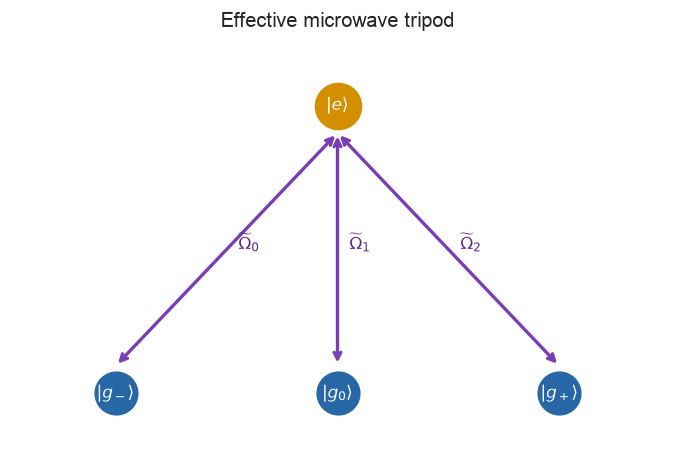

In [6]:
# Project each bare, nuclear-spin-preserving MW matrix element onto |e>.
include_c_projection = True
# Paper Eq. (3) uses exp(-i*phi_m) multiplying |e><g_m|.
Omega_complex = mw_Omega_MHz*np.exp(-1j*mw_phase_rad)
Omega_eff = np.conj(c)*Omega_complex if include_c_projection else Omega_complex

# Basis: |g_->, |g_0>, |g_+>, |e>
# Assemble the four-state RWA Hamiltonian in [g-, g0, g+, e].
H_tripod = np.diag([*mw_detuning_MHz, 0.0]).astype(complex)
for j in range(3):
    H_tripod[3,j] = Omega_eff[j]/2
    H_tripod[j,3] = np.conj(Omega_eff[j])/2
# Store the effective tripod as a QuaCCAToo quantum system.
tripod_system = QSys(H0=Qobj(H_tripod), rho0=basis(4,0), observable=Qobj(np.eye(4)), units_H0='MHz')

print('Effective Ω̃_j (MHz):', Omega_eff)
print('H_tripod / h (MHz):\n', H_tripod)
assert np.allclose(H_tripod, H_tripod.conj().T)

fig, ax = plt.subplots(figsize=(7,4.6))
gx = np.array([-1.5,0,1.5]); ex, ey = 0,2.1
ax.scatter(gx, np.zeros(3), s=650, color='#2767a5', zorder=3)
ax.scatter([ex],[ey], s=760, color='#d29000', zorder=3)
for x, lab in zip(gx,[r'$|g_-\rangle$',r'$|g_0\rangle$',r'$|g_+\rangle$']): ax.text(x,0,lab,color='white',ha='center',va='center')
ax.text(ex,ey,r'$|e\rangle$',color='white',ha='center',va='center')
for j,x in enumerate(gx):
    ax.annotate('', xy=(ex,ey-.2), xytext=(x,.2), arrowprops=dict(arrowstyle='<->',lw=2,color='#7a3db8'))
    ax.text((x+ex)/2+.08,ey/2,rf'$\widetilde{{\Omega}}_{j}$',color='#5b2788')
ax.set(xlim=(-2.2,2.2),ylim=(-.5,2.6),title='Effective microwave tripod'); ax.axis('off'); plt.show()

#### Reading the tripod connectivity diagram

**How it was generated.** The three blue nodes represent $|g_-\rangle$, $|g_0\rangle$, and $|g_+\rangle$; the orange node is the RF-dressed ancilla $|e\rangle$. Each double arrow corresponds to one complex matrix element $\widetilde\Omega_m/2$ in `H_tripod`.

**Physical intuition.** All three long-lived ground states communicate through one common ancilla, but there are no direct ground-to-ground links. Consequently, one bright ground superposition couples to $|e\rangle$, while two orthogonal combinations form the degenerate dark subspace.

### Direct verification against Equation (3) of the paper

The paper writes

$$H(t)=\frac{\hbar}{2}\sum_{m\in\{-,0,+\}}\left[\Omega_m(t)e^{-i\phi_m(t)}|e\rangle\langle g_m|+\mathrm{h.c.}\right].$$

The verification below reconstructs this operator independently in the notebook basis $[|g_-\rangle,|g_0\rangle,|g_+\rangle,|e\rangle]$ and compares every matrix element with `H_tripod`. In this implementation, `mw_Omega_MHz` denotes the bare nuclear-spin-preserving microwave rates and `conj(c)` projects them onto the selected dressed state. Thus the paper's effective coupling is represented numerically as $\Omega_m^{(\mathrm{paper})}=c_m^*\Omega_m^{(\mathrm{bare})}$. Detuning terms are checked separately because the ideal interaction-picture Equation (3) contains none.

In [7]:
# Reconstruct paper Eq. (3) independently from ket-bra outer products.
# Basis indices 0,1,2 are |g_->, |g_0>, |g_+>; index 3 is |e>.
paper_basis = np.eye(4, dtype=complex)
g_kets = [paper_basis[:, j] for j in range(3)]
e_basis_ket = paper_basis[:, 3]

# Projection of a nuclear-spin-preserving bare MW drive onto the RF-dressed
# ancilla. The explicit phase factor follows Eq. (3): exp(-i*phi_m).
Omega_paper = np.conj(c) * mw_Omega_MHz
H_eq3 = np.zeros((4, 4), dtype=complex)
for m in range(3):
    ket_e_bra_g = np.outer(e_basis_ket, np.conj(g_kets[m]))
    forward_term = Omega_paper[m] * np.exp(-1j * mw_phase_rad[m]) * ket_e_bra_g
    H_eq3 += 0.5 * (forward_term + forward_term.conj().T)

# Equation (3) is the resonant interaction Hamiltonian. The notebook permits
# optional ground-state detunings, so remove that diagonal part before comparing.
H_tripod_interaction = H_tripod - np.diag([*mw_detuning_MHz, 0.0])
elementwise_difference = H_tripod_interaction - H_eq3

print('H from paper Eq. (3) / h (MHz):\n', H_eq3)
print('\nInteraction part of coded H_tripod / h (MHz):\n', H_tripod_interaction)
print('\nMaximum elementwise difference:', np.max(np.abs(elementwise_difference)))

# These tests verify the basis order, 1/2 factor, phase sign, dressed-state
# projection, Hermitian-conjugate placement, and absence of ground-ground links.
assert np.allclose(H_tripod_interaction, H_eq3)
assert np.allclose(H_eq3, H_eq3.conj().T)
assert np.allclose(H_eq3[:3, :3], 0.0)
assert np.isclose(H_eq3[3, 0], 0.5*np.conj(c[0])*mw_Omega_MHz[0]*np.exp(-1j*mw_phase_rad[0]))
assert np.isclose(H_eq3[3, 1], 0.5*np.conj(c[1])*mw_Omega_MHz[1]*np.exp(-1j*mw_phase_rad[1]))
assert np.isclose(H_eq3[3, 2], 0.5*np.conj(c[2])*mw_Omega_MHz[2]*np.exp(-1j*mw_phase_rad[2]))

print('\nPASS: H_tripod reproduces Equation (3) exactly under the stated projection convention.')


H from paper Eq. (3) / h (MHz):
 [[ 0.     +0.j       0.     +0.j       0.     +0.j      -0.05609-0.j     ]
 [ 0.     +0.j       0.     +0.j       0.     +0.j      -0.03863+0.0669j ]
 [ 0.     +0.j       0.     +0.j       0.     +0.j       0.00817+0.04657j]
 [-0.05609+0.j      -0.03863-0.0669j   0.00817-0.04657j  0.     +0.j     ]]

Interaction part of coded H_tripod / h (MHz):
 [[ 0.     +0.j       0.     +0.j       0.     +0.j      -0.05609-0.j     ]
 [ 0.     +0.j       0.     +0.j       0.     +0.j      -0.03863+0.0669j ]
 [ 0.     +0.j       0.     +0.j       0.     +0.j       0.00817+0.04657j]
 [-0.05609+0.j      -0.03863-0.0669j   0.00817-0.04657j  0.     +0.j     ]]

Maximum elementwise difference: 1.734723475976807e-18

PASS: H_tripod reproduces Equation (3) exactly under the stated projection convention.


### Verification of the paper's bright and dark states (Equations 4–6)

Define the full complex coefficient in Equation (3) as

$$K_m\equiv\Omega_m e^{-i\phi_m}.$$

In the notebook, `Omega_eff[m]` is exactly $K_m$. Therefore the paper's parameters can be recovered without choosing a special phase convention:

$$\Omega_m=|K_m|,\qquad \phi_m=-\arg K_m.$$

Equation (4) then becomes

$$|B\rangle=\frac{1}{\Omega_{\rm tot}}\sum_m K_m^*|g_m\rangle,
\qquad \Omega_{\rm tot}=\sqrt{|K_-|^2+|K_0|^2+|K_+|^2}.$$

Equations (5) and (6) give a convenient orthonormal basis for the two-dimensional ground-state subspace orthogonal to $|B\rangle$. The code below constructs those states literally, embeds them in the notebook basis $[|g_-\rangle,|g_0\rangle,|g_+\rangle,|e\rangle]$, and verifies:

1. $\langle B|B\rangle=\langle D_a|D_a\rangle=1$;
2. $\langle B|D_a\rangle=0$ and $\langle D_1|D_2\rangle=0$;
3. $H_{\rm tripod}|D_a\rangle=0$;
4. $H_{\rm tripod}|B\rangle=(\Omega_{\rm tot}/2)|e\rangle$ and $H_{\rm tripod}|e\rangle=(\Omega_{\rm tot}/2)|B\rangle$.

These statements apply to the resonant interaction part of Equation (3). Nonzero unequal detunings would generally lift the ideal dark-state degeneracy.

In [8]:
# The notebook's effective complex couplings are the coefficients
# K_m = Omega_m * exp(-i phi_m) that multiply |e><g_m| in Eq. (3).
K_minus, K_zero, K_plus = Omega_eff
Omega_paper = np.abs(Omega_eff)
phi_paper = -np.angle(Omega_eff)
Omega_tot = np.linalg.norm(Omega_paper)

# Use four-component vectors in [|g_->, |g_0>, |g_+>, |e>].
g_minus, g_zero, g_plus, e_vec = np.eye(4, dtype=complex)

# Paper Eq. (4): |B> = sum_m Omega_m exp(+i phi_m)|g_m>/Omega_tot.
# Since K_m = Omega_m exp(-i phi_m), the bright-state coefficient is K_m*.
B = (np.conj(K_minus)*g_minus
     + np.conj(K_zero)*g_zero
     + np.conj(K_plus)*g_plus) / Omega_tot

# Shared normalization used by the paper's Eqs. (5) and (6).
Omega_minus_zero = np.sqrt(Omega_paper[0]**2 + Omega_paper[1]**2)
if np.isclose(Omega_minus_zero, 0.0):
    raise ValueError('Equations (5)-(6) require at least one of Omega_- or Omega_0 to be nonzero.')

# Paper Eq. (5):
# |D1> = [Omega_0 e^(-i phi_0)|g_-> - Omega_- e^(-i phi_-)|g_0>]
#        / sqrt(Omega_-^2 + Omega_0^2).
D1 = (K_zero*g_minus - K_minus*g_zero) / Omega_minus_zero

# Paper Eq. (6), rewritten using K_m:
# |D2> = {K_+[K_-*|g_-> + K_0*|g_0>]
#          - (Omega_-^2 + Omega_0^2)|g_+>}
#        / [Omega_tot sqrt(Omega_-^2 + Omega_0^2)].
D2 = (K_plus*(np.conj(K_minus)*g_minus + np.conj(K_zero)*g_zero)
      - Omega_minus_zero**2*g_plus) / (Omega_tot*Omega_minus_zero)

# Collect the states so the Gram matrix checks all norms and overlaps at once.
paper_states = np.column_stack([B, D1, D2])
gram_matrix = paper_states.conj().T @ paper_states

# H_tripod_interaction was independently verified against paper Eq. (3) above.
H_on_B = H_tripod_interaction @ B
H_on_D1 = H_tripod_interaction @ D1
H_on_D2 = H_tripod_interaction @ D2
H_on_e = H_tripod_interaction @ e_vec

print('Paper effective amplitudes Omega_m (MHz):', Omega_paper)
print('Paper effective phases phi_m (rad):', phi_paper)
print('Omega_tot (MHz):', Omega_tot)
print('\nGram matrix for [B, D1, D2]:\n', gram_matrix)
print('\n||H|D1>||:', np.linalg.norm(H_on_D1))
print('||H|D2>||:', np.linalg.norm(H_on_D2))
print('Bright-to-excited residual:', np.linalg.norm(H_on_B - 0.5*Omega_tot*e_vec))
print('Excited-to-bright residual:', np.linalg.norm(H_on_e - 0.5*Omega_tot*B))

# Numerical verification of Eqs. (4)-(6) against the coded tripod Hamiltonian.
assert np.allclose(gram_matrix, np.eye(3))
assert np.allclose(H_on_D1, 0.0)
assert np.allclose(H_on_D2, 0.0)
assert np.allclose(H_on_B, 0.5*Omega_tot*e_vec)
assert np.allclose(H_on_e, 0.5*Omega_tot*B)

# The two dark states have eigenvalue zero; the bright/ancilla sector has
# eigenvalues +/- Omega_tot/2 in frequency units.
tripod_eigenvalues = np.linalg.eigvalsh(H_tripod_interaction)
expected_eigenvalues = np.array([-0.5*Omega_tot, 0.0, 0.0, 0.5*Omega_tot])
assert np.allclose(tripod_eigenvalues, expected_eigenvalues)

print('\nPASS: the paper bright state and both dark states agree with the coded tripod Hamiltonian.')


Paper effective amplitudes Omega_m (MHz): [0.11217 0.15451 0.09455]
Paper effective phases phi_m (rad): [-3.14159  2.0944   1.3972 ]
Omega_tot (MHz): 0.21306444108062245

Gram matrix for [B, D1, D2]:
 [[ 1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j -0.-0.j]
 [ 0.-0.j -0.+0.j  1.+0.j]]

||H|D1>||: 3.191878695571546e-18
||H|D2>||: 3.878959614448864e-18
Bright-to-excited residual: 2.7755575615628914e-17
Excited-to-bright residual: 1.5515838457795457e-17

PASS: the paper bright state and both dark states agree with the coded tripod Hamiltonian.


## 4. Non-Abelian dark-state holonomy

### Section overview: Equations (7)–(10)

Equation (7) describes the Wilczek–Zee holonomy in the two-dimensional dark subspace,

$$U(C)=\mathcal P\exp\!\left[-\oint_C \mathbf A\cdot d\boldsymbol\lambda\right],
\qquad A_{\alpha,ab}=\langle D_a|\partial_{\lambda_\alpha}D_b\rangle.$$

The paper proposes two closed phase loops,

$$C_1:\ \phi_-(t):0\rightarrow2\pi,\quad \phi_0=\phi_+=0,$$
$$C_2:\ \phi_+(t):0\rightarrow2\pi,\quad \phi_0=\phi_-=0,$$

using Equation (10),

$$\phi(t)=2\pi\sin^2\!\left(\frac{\pi t}{2T}\right).$$

The effective amplitudes are held fixed. Because the RF coefficients $c_m$ can carry phases, an experiment would compensate them in the programmed microwave phases so that the *effective* tripod phases begin at zero. The simulation below works directly in the verified effective basis $[g_-,g_0,g_+,e]$ and uses the effective amplitudes `Omega_paper` found above.

Each QuaCCAToo `PulsedSim` run starts in one of the two paper dark states, applies a loop (or an ordered pair of loops), and returns the final state. Projecting both propagated basis vectors back onto $\{D_1,D_2\}$ produces the measured $2\times2$ dark-subspace evolution. Since the ideal dark eigenvalue is zero, this projected unitary is geometric rather than dynamical. Finite-time leakage quantifies imperfect adiabaticity.

### 4.1 Smooth phase loops

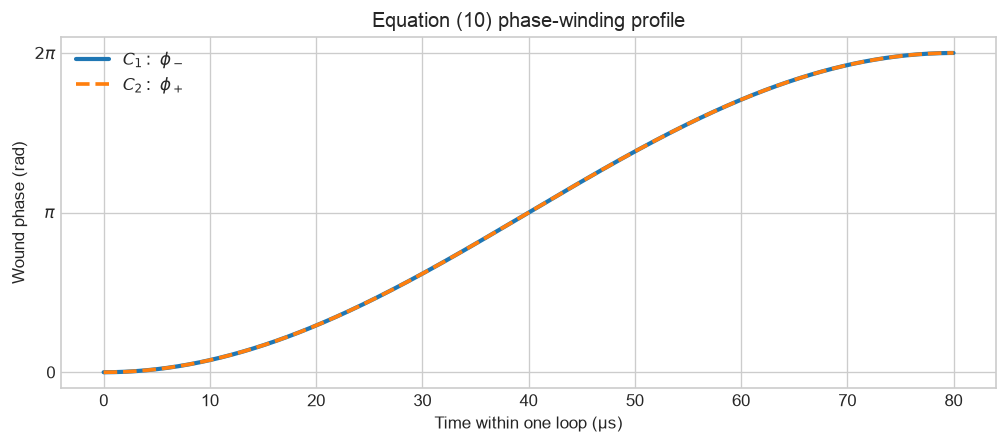

In [9]:
# -----------------------------------------------------------------------------
# A. Experimental settings and the closed-loop phase waveform from Eq. (10)
# -----------------------------------------------------------------------------
loop_duration_us = 80.0       # Increase this to improve adiabatic following.
loop_time_steps = 1001        # Solver samples per loop segment.
Omega_loop = Omega_paper.copy()  # Fixed effective amplitudes [Omega_-, Omega_0, Omega_+].

def phase_winding(local_time_us, duration_us):
    """Evaluate the smooth closed-loop phase profile from paper Eq. (10).

    Parameters
    ----------
    local_time_us : float or numpy.ndarray
        Physical time within one loop segment, measured in microseconds. Values
        outside the segment are clipped to its endpoints.
    duration_us : float
        Positive loop duration T in microseconds.

    Returns
    -------
    float or numpy.ndarray
        Phase in radians, ranging smoothly from 0 to 2*pi. Physically, this is
        the programmed phase of the active effective microwave coupling.
    """
    # Equation (10): a smooth 0 -> 2*pi winding with zero endpoint velocity.
    local_time_us = np.clip(local_time_us, 0.0, duration_us)
    return 2*np.pi*np.sin(np.pi*local_time_us/(2*duration_us))**2

# Plot Eq. (10) for both controls. They have the same shape but act on
# different microwave legs in C1 and C2.
t_loop_plot = np.linspace(0.0, loop_duration_us, 800)
phi_loop_plot = phase_winding(t_loop_plot, loop_duration_us)
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(t_loop_plot, phi_loop_plot, lw=2.5, label=r'$C_1:\ \phi_-$')
ax.plot(t_loop_plot, phi_loop_plot, '--', lw=2.2, label=r'$C_2:\ \phi_+$')
ax.set(xlabel='Time within one loop (µs)', ylabel='Wound phase (rad)',
       yticks=[0, np.pi, 2*np.pi], yticklabels=['0', r'$\pi$', r'$2\pi$'],
       title='Equation (10) phase-winding profile')
ax.legend(); fig.tight_layout(); plt.show()


#### Reading the phase-winding figure

**How it was generated.** The curve evaluates Equation (10) from $t=0$ to $T=80\,\mu$s. The solid and dashed traces have the same mathematical envelope; $C_1$ applies it to $\phi_-$, whereas $C_2$ applies it to $\phi_+$.

**Physical intuition.** Each phase completes one closed $2\pi$ circuit, returning the Hamiltonian to its starting value. The horizontal slope vanishes at both endpoints, suppressing sudden nonadiabatic excitation when a loop begins or ends.

### 4.2 Dark-basis preparation and IQ control decomposition

This subsection reconstructs the paper's dark basis at the common loop endpoint and decomposes each complex tripod coupling into Hermitian in-phase and quadrature operators. The resulting six operators and six envelope functions are the inputs passed to QuaCCAToo.

In [10]:
# -----------------------------------------------------------------------------
# B. Reconstruct the paper's dark basis at the common loop endpoint phi_m = 0
# -----------------------------------------------------------------------------
Om, O0, Op = Omega_loop
Ominus0 = np.sqrt(Om**2 + O0**2)
Otot_loop = np.linalg.norm(Omega_loop)

# The loops start and finish at phases equivalent to zero, so the same dark
# basis is used for preparation and final projection.
D1_loop = (O0*g_minus - Om*g_zero) / Ominus0
D2_loop = (Op*(Om*g_minus + O0*g_zero) - Ominus0**2*g_plus) / (Otot_loop*Ominus0)
dark_basis_loop = np.column_stack([D1_loop, D2_loop])
assert np.allclose(dark_basis_loop.conj().T @ dark_basis_loop, np.eye(2))


# -----------------------------------------------------------------------------
# C. Express Eq. (3) as six Hermitian in-phase/quadrature control operators
# -----------------------------------------------------------------------------
control_operators = []
for m in range(3):
    A_m = np.outer(e_vec, np.conj(np.eye(4, dtype=complex)[:, m]))  # |e><g_m|
    X_m = A_m + A_m.conj().T
    Y_m = -1j*A_m + 1j*A_m.conj().T
    control_operators.extend([Qobj(0.5*Omega_loop[m]*X_m),
                              Qobj(0.5*Omega_loop[m]*Y_m)])

def loop_shapes(active_leg, start_time_us, duration_us):
    """Create the six IQ-envelope functions required by one tripod loop.

    Parameters
    ----------
    active_leg : int
        Index 0, 1, or 2 identifying which effective phase is wound. The paper
        uses 0 for C1 (phi_-) and 2 for C2 (phi_+).
    start_time_us : float
        Absolute physical start time of this pulse segment in microseconds.
    duration_us : float
        Duration T of the loop segment in microseconds.

    Returns
    -------
    list of callable
        Six dimensionless functions ordered [cos(phi_-), sin(phi_-),
        cos(phi_0), sin(phi_0), cos(phi_+), sin(phi_+)]. Multiplying these
        envelopes by the X/Y control operators reconstructs paper Eq. (3).
    """
    # Return cos(phi_m) and sin(phi_m) envelopes for all three tripod legs.
    shapes = []
    for leg in range(3):
        for quadrature in ('x', 'y'):
            def shape(solver_time, leg=leg, quadrature=quadrature, **_):
                """Map QuaCCAToo solver time to one dimensionless IQ weight.

                `solver_time` is QuaCCAToo's 2*pi-scaled time coordinate; `leg`
                and `quadrature` are captured control labels. The returned float
                is cos(phi) or sin(phi), i.e. the instantaneous physical weight
                multiplying one Hermitian microwave control operator.
                """
                # QuaCCAToo evolves with solver time 2*pi*t for MHz-us units.
                physical_time_us = solver_time/(2*np.pi)
                local_time_us = physical_time_us - start_time_us
                phi = phase_winding(local_time_us, duration_us) if leg == active_leg else 0.0
                return np.cos(phi) if quadrature == 'x' else np.sin(phi)
            shapes.append(shape)
    return shapes


### 4.3 QuaCCAToo evolution and holonomy extraction

For each logical basis input, `PulsedSim.add_pulse` integrates the time-dependent tripod Hamiltonian and updates the state sequentially. Propagating both $|D_1\rangle$ and $|D_2\rangle$ reconstructs the full logical operation. Projection, polar decomposition, and global-phase removal then yield the corresponding $SU(2)$ holonomies.

In [11]:
# -----------------------------------------------------------------------------
# D. Run C1/C2 with QuaCCAToo and project the result onto the dark subspace
# -----------------------------------------------------------------------------
loop_to_leg = {'C1': 0, 'C2': 2}  # C1 winds phi_-; C2 winds phi_+.

def propagate_dark_input(initial_vector, loop_order):
    """Propagate one logical dark-state input through an ordered loop sequence.

    Parameters
    ----------
    initial_vector : numpy.ndarray, shape (4,)
        Normalized state amplitudes in [g_-, g_0, g_+, e]. It should normally
        lie in the initial dark subspace.
    loop_order : tuple of str
        Chronological loop names, for example ('C1','C2'). The first tuple item
        is applied first, so this example implements U(C2)U(C1).

    Returns
    -------
    numpy.ndarray, shape (4,)
        Final complex state amplitudes. Physically, this is the state after
        QuaCCAToo has time-ordered all requested microwave phase loops.
    """
    # Apply an ordered sequence of loops to one initial dark-state vector.
    system = QSys(
        H0=Qobj(np.zeros((4, 4), dtype=complex)),
        rho0=Qobj(initial_vector, dims=[[4], [1]]),
        observable=None,
        units_H0='MHz',
    )
    experiment = PulsedSim(system)

    for segment, loop_name in enumerate(loop_order):
        segment_start = segment*loop_duration_us
        experiment.add_pulse(
            duration=loop_duration_us,
            h1=control_operators,
            pulse_shape=loop_shapes(loop_to_leg[loop_name], segment_start, loop_duration_us),
            pulse_params={},
            time_steps=loop_time_steps,
            options={'atol': 1e-10, 'rtol': 1e-9, 'nsteps': 100000},
        )
    return experiment.rho.full().ravel()

def projected_dark_evolution(loop_order):
    """Reconstruct the loop evolution projected onto the logical dark basis.

    Parameters
    ----------
    loop_order : tuple of str
        Chronological sequence containing 'C1' and/or 'C2'.

    Returns
    -------
    projected : numpy.ndarray, shape (2,2)
        Dark-subspace transition-amplitude matrix; column b is obtained from an
        initial |D_b>. In the adiabatic limit this is the geometric holonomy.
    final_vectors : numpy.ndarray, shape (4,2)
        Full final physical states before projection.
    mean_leakage : float
        Average final probability outside span{|D1>,|D2>} for the two inputs.
    """
    # Columns are the final states from initial D1 and D2, projected onto D.
    final_vectors = np.column_stack([
        propagate_dark_input(dark_basis_loop[:, column], loop_order)
        for column in range(2)
    ])
    projected = dark_basis_loop.conj().T @ final_vectors
    mean_leakage = 1.0 - np.trace(projected.conj().T @ projected).real/2.0
    return projected, final_vectors, mean_leakage

def nearest_unitary(matrix):
    """Extract the unitary part of a nearly unitary projected evolution.

    Parameters
    ----------
    matrix : numpy.ndarray, shape (2,2)
        Projected dark evolution, which may be slightly nonunitary from leakage.

    Returns
    -------
    numpy.ndarray, shape (2,2)
        Nearest unitary matrix from the polar decomposition. Physically, it
        isolates the coherent logical operation from small norm loss.
    """
    # Remove small nonunitarity due to finite-time leakage using polar decomposition.
    left, _, right_h = np.linalg.svd(matrix)
    return left @ right_h

def remove_global_phase(unitary):
    """Choose an SU(2) representative by removing a global U(1) phase.

    Parameters
    ----------
    unitary : numpy.ndarray, shape (2,2)
        Unitary dark-subspace operation.

    Returns
    -------
    numpy.ndarray, shape (2,2)
        Determinant-one matrix with the same observable logical action. This is
        the non-Abelian SU(2) Wilczek–Zee holonomy up to branch sign.
    """
    # Convert a 2x2 unitary to an SU(2) representative (global phase removed).
    return unitary / np.sqrt(np.linalg.det(unitary))

# Single-loop holonomies and the two experimental orderings.
M_C1, _, leakage_C1 = projected_dark_evolution(('C1',))
M_C2, _, leakage_C2 = projected_dark_evolution(('C2',))
M_C2C1, final_C2C1, leakage_C2C1 = projected_dark_evolution(('C1', 'C2'))  # C2 after C1
M_C1C2, final_C1C2, leakage_C1C2 = projected_dark_evolution(('C2', 'C1'))  # C1 after C2

# Extract unitary geometric parts and remove their physically irrelevant global phases.
U_C1 = remove_global_phase(nearest_unitary(M_C1))
U_C2 = remove_global_phase(nearest_unitary(M_C2))
U_C2C1 = remove_global_phase(nearest_unitary(M_C2C1))
U_C1C2 = remove_global_phase(nearest_unitary(M_C1C2))

commutator = U_C2 @ U_C1 - U_C1 @ U_C2
commutator_norm = np.linalg.norm(commutator, ord='fro')
order_difference = np.linalg.norm(U_C2C1 - U_C1C2, ord='fro')

print('U(C1) in [D1,D2]:\n', U_C1)
print('\nU(C2) in [D1,D2]:\n', U_C2)
print('\nU(C2 o C1):\n', U_C2C1)
print('\nU(C1 o C2):\n', U_C1C2)
print('\n||[U(C2), U(C1)]||_F =', commutator_norm)
print('||U(C2 o C1) - U(C1 o C2)||_F =', order_difference)
print('Mean dark leakage C1, C2, C2 o C1, C1 o C2 =',
      leakage_C1, leakage_C2, leakage_C2C1, leakage_C1C2)

# A nonzero commutator and order difference are the non-Abelian signature.
assert commutator_norm > 1e-3
assert order_difference > 1e-3
assert max(leakage_C1, leakage_C2, leakage_C2C1, leakage_C1C2) < 0.02


U(C1) in [D1,D2]:
 [[ 0.63622+0.6264j  -0.     +0.45038j]
 [ 0.     +0.45038j  0.63622-0.6264j ]]

U(C2) in [D1,D2]:
 [[ 0.80927-0.58743j -0.     -0.j     ]
 [ 0.     -0.j       0.80927+0.58743j]]

U(C2 o C1):
 [[ 0.88283+0.13318j  0.26459+0.3645j ]
 [-0.26459+0.3645j   0.88283-0.13318j]]

U(C1 o C2):
 [[ 0.88283+0.13318j -0.26459+0.3645j ]
 [ 0.26459+0.3645j   0.88283-0.13318j]]

||[U(C2), U(C1)]||_F = 0.7483217778582957
||U(C2 o C1) - U(C1 o C2)||_F = 0.7483760972328714
Mean dark leakage C1, C2, C2 o C1, C1 o C2 = 4.31878053316348e-05 2.3330755062445085e-05 5.4033924087315555e-05 5.4034080012366204e-05


### 4.4 Order-swap measurement

The following plots emulate the paper's final-only measurement. Both sequences start in $(|D_1\rangle+|D_2\rangle)/\sqrt2$, an order-sensitive logical input. The first compares final populations in the logical dark basis; the second displays the magnitude of the two extracted $SU(2)$ holonomies. Different final populations for the two loop orders, together with a nonzero matrix commutator, demonstrate that the geometric operations are non-Abelian.

In [12]:
# Use an order-sensitive logical input. A single |D1> input can hide the
# noncommutativity in phases because the two symmetric orders may have the same
# population magnitudes even when their SU(2) matrices are different.
logical_input = np.array([1.0, 1.], dtype=complex)/np.sqrt(2)

def final_populations(projected_matrix, input_amplitudes):
    """Convert a projected logical evolution into measurable final populations.

    Parameters
    ----------
    projected_matrix : numpy.ndarray, shape (2,2)
        Dark-subspace transition-amplitude matrix for one ordered loop sequence.
    input_amplitudes : numpy.ndarray, shape (2,)
        Normalized logical amplitudes in the [D1,D2] basis.

    Returns
    -------
    numpy.ndarray, shape (3,)
        [P_D1, P_D2, leakage]. The first two entries are final logical-state
        populations; the third is final probability outside the dark subspace.
    """
    final_dark_amplitudes = projected_matrix @ input_amplitudes
    dark_pops = np.abs(final_dark_amplitudes)**2
    return np.array([dark_pops[0], dark_pops[1], max(0.0, 1.0-dark_pops.sum())])

pops_C2C1 = final_populations(M_C2C1, logical_input)
pops_C1C2 = final_populations(M_C1C2, logical_input)


#### Time-resolved populations through the two loop orderings

The same order-sensitive logical input is now propagated while recording the four effective-basis populations. The left panel applies $C_1$ first and then $C_2$; the right panel reverses the chronological order.


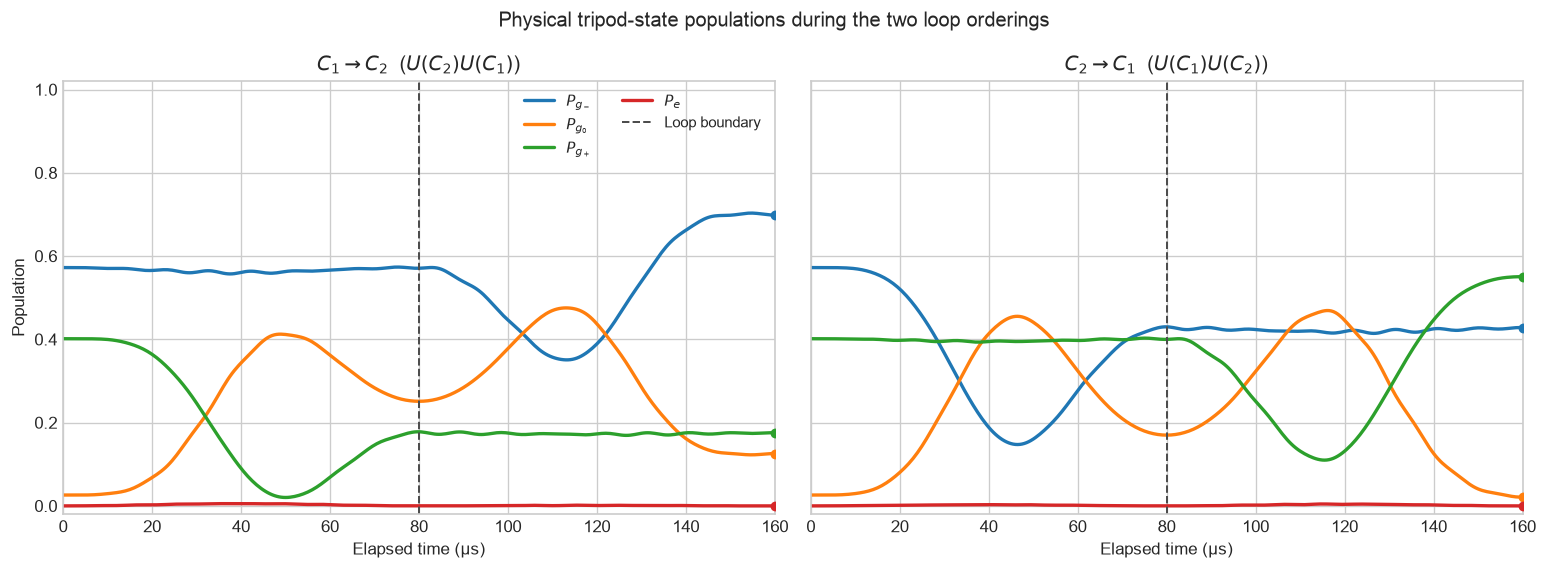

Final [P_g-, P_g0, P_g+, P_e] after C1 -> C2: [0.69889 0.12545 0.17565 0.00001]
Final [P_g-, P_g0, P_g+, P_e] after C2 -> C1: [0.42828 0.02109 0.55063 0.     ]
Final physical-population contrast: 0.4740537585793464


In [13]:
def propagate_population_trajectory(initial_vector, loop_order, samples_per_loop=160):
    """Record physical-state populations during an ordered pair of phase loops.

    Parameters
    ----------
    initial_vector : numpy.ndarray, shape (4,)
        Normalized initial amplitudes in the effective basis
        [g_-, g_0, g_+, e].
    loop_order : tuple of str
        Chronological sequence of loop labels. For example, ('C1', 'C2')
        means C1 is applied first and C2 second.
    samples_per_loop : int
        Number of equally spaced population-reporting intervals per loop.

    Returns
    -------
    times_us : numpy.ndarray
        Physical reporting times in microseconds, including the initial time.
    populations : numpy.ndarray, shape (N, 4)
        Populations [P_g-, P_g0, P_g+, P_e] at each reporting time. These are
        expectation values in the effective tripod basis and sum to one.
    final_vector : numpy.ndarray, shape (4,)
        Final complex state amplitudes after the complete ordered sequence.
    """
    if not isinstance(samples_per_loop, int) or samples_per_loop <= 0:
        raise ValueError("samples_per_loop must be a positive integer")

    initial_vector = np.asarray(initial_vector, dtype=complex)
    if initial_vector.shape != (4,):
        raise ValueError("initial_vector must have shape (4,)")
    initial_vector = initial_vector / np.linalg.norm(initial_vector)

    system = QSys(
        H0=Qobj(np.zeros((4, 4), dtype=complex)),
        rho0=Qobj(initial_vector, dims=[[4], [1]]),
        observable=None,
        units_H0='MHz',
    )
    experiment = PulsedSim(system)

    times_us = [0.0]
    populations = [np.abs(initial_vector)**2]
    interval_us = loop_duration_us / samples_per_loop

    for segment, loop_name in enumerate(loop_order):
        loop_start_us = segment * loop_duration_us
        shapes = loop_shapes(
            loop_to_leg[loop_name],
            loop_start_us,
            loop_duration_us,
        )
        for _ in range(samples_per_loop):
            experiment.add_pulse(
                duration=interval_us,
                h1=control_operators,
                pulse_shape=shapes,
                pulse_params={},
                time_steps=4,
                options={'atol': 1e-10, 'rtol': 1e-9, 'nsteps': 100000},
            )
            state_vector = experiment.rho.full().ravel()
            times_us.append(experiment.total_time)
            populations.append(np.abs(state_vector)**2)

    populations = np.asarray(populations)
    assert np.allclose(populations.sum(axis=1), 1.0, atol=1e-8)
    return np.asarray(times_us), populations, experiment.rho.full().ravel()


# Prepare the same physical initial state for both chronological orderings.
physical_logical_input = dark_basis_loop @ logical_input

times_C2C1_us, trajectory_C2C1, final_trajectory_C2C1 = propagate_population_trajectory(
    physical_logical_input,
    ('C1', 'C2'),
)
times_C1C2_us, trajectory_C1C2, final_trajectory_C1C2 = propagate_population_trajectory(
    physical_logical_input,
    ('C2', 'C1'),
)

# Confirm that segmented reporting reproduces the final states previously
# obtained by the one-pulse-per-loop QuaCCAToo calculations.
reference_final_C2C1 = final_C2C1 @ logical_input
reference_final_C1C2 = final_C1C2 @ logical_input
assert np.allclose(
    np.abs(final_trajectory_C2C1)**2,
    np.abs(reference_final_C2C1)**2,
    atol=3e-5,
)
assert np.allclose(
    np.abs(final_trajectory_C1C2)**2,
    np.abs(reference_final_C1C2)**2,
    atol=3e-5,
)

population_labels = (r'$P_{g_-}$', r'$P_{g_0}$', r'$P_{g_+}$', r'$P_e$')
population_colors = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True, sharey=True)
for ax, times_us, populations, title in zip(
    axes,
    (times_C2C1_us, times_C1C2_us),
    (trajectory_C2C1, trajectory_C1C2),
    (r'$C_1\rightarrow C_2$  ($U(C_2)U(C_1)$)',
     r'$C_2\rightarrow C_1$  ($U(C_1)U(C_2)$)'),
):
    for state_index, (label, color) in enumerate(zip(population_labels, population_colors)):
        ax.plot(times_us, populations[:, state_index], lw=2.0, color=color, label=label)
        ax.scatter(times_us[-1], populations[-1, state_index], s=24, color=color, zorder=3)
    ax.axvline(loop_duration_us, color='0.3', ls='--', lw=1.2, label='Loop boundary')
    ax.set(
        xlabel='Elapsed time (µs)',
        title=title,
        xlim=(0.0, 2.0 * loop_duration_us),
        ylim=(-0.02, 1.02),
    )

axes[0].set_ylabel('Population')
axes[0].legend(ncol=2, fontsize=9)
fig.suptitle('Physical tripod-state populations during the two loop orderings')
fig.tight_layout()
plt.show()

final_physical_pops_C2C1 = trajectory_C2C1[-1]
final_physical_pops_C1C2 = trajectory_C1C2[-1]
print('Final [P_g-, P_g0, P_g+, P_e] after C1 -> C2:', final_physical_pops_C2C1)
print('Final [P_g-, P_g0, P_g+, P_e] after C2 -> C1:', final_physical_pops_C1C2)
print(
    'Final physical-population contrast:',
    np.linalg.norm(final_physical_pops_C2C1 - final_physical_pops_C1C2),
)


#### Comparing the two population trajectories

**How the plots were generated.** Both panels begin with the same $(|D_1\rangle+|D_2\rangle)/\sqrt2$ logical state. QuaCCAToo applies the two smooth phase loops sequentially while the state is sampled in the physical effective basis $[g_-,g_0,g_+,e]$. The dashed line marks the end of the first loop, and the dots identify the final populations after the second loop.

**Final populations.** In the ordering $C_1\rightarrow C_2$, the final $[P_{g_-},P_{g_0},P_{g_+},P_e]$ is approximately $[0.699,0.125,0.176,10^{-5}]$. For $C_2\rightarrow C_1$, it is approximately $[0.428,0.021,0.551,0]$. Their physical-population contrast is $0.474$, while both results remain normalized.

**Comparison and physical meaning.** The ancilla population remains small because an adiabatic loop ideally follows the two-dimensional dark subspace. Nevertheless, the three ground-state populations evolve because the instantaneous dark-state basis changes as the microwave phase winds. Reversing the loop order produces different final ground-state populations even though both paths return the Hamiltonian to the same endpoint. This order-dependent redistribution is the population-level signature of the non-commuting Wilczek–Zee holonomies. Small transient or final $P_e$ is finite-time nonadiabatic leakage in this ideal four-level model.


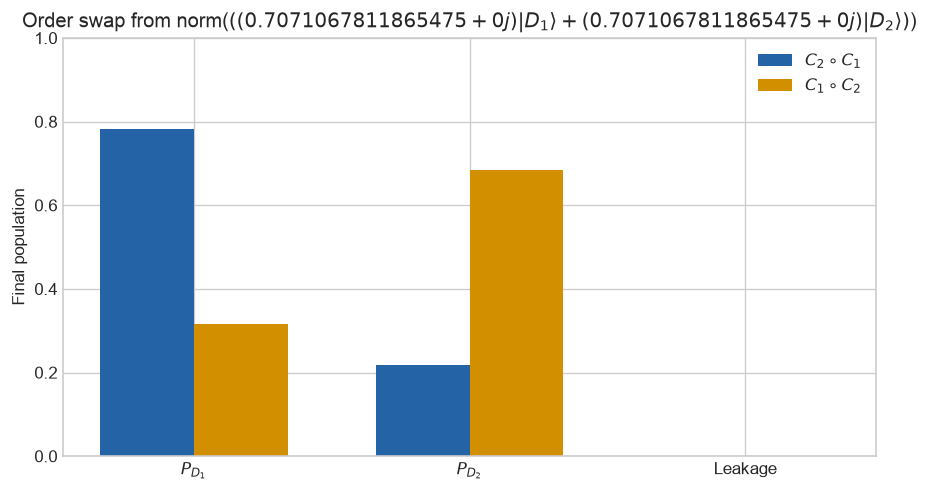

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(3); width = 0.34
ax.bar(x-width/2, pops_C2C1, width, label=r'$C_2\circ C_1$', color='#2463a6')
ax.bar(x+width/2, pops_C1C2, width, label=r'$C_1\circ C_2$', color='#d29000')
ax.set(xticks=x, xticklabels=[r'$P_{D_1}$', r'$P_{D_2}$', 'Leakage'],
       ylabel='Final population', ylim=(0, 1),
       title=fr'Order swap from norm($({logical_input[0]}|D_1\rangle+{logical_input[1]}|D_2\rangle)$)')
ax.legend(); fig.tight_layout(); plt.show()


#### Reading the order-swap population plot

**How it was generated.** The same logical input $(|D_1\rangle+|D_2\rangle)/\sqrt2$ is propagated through both chronological loop orders. The final states are projected onto $D_1$ and $D_2$; the remaining norm is reported as final leakage.

**Physical intuition.** The large redistribution of population between the blue and orange sequences demonstrates that the result depends on loop order. This is a directly measurable signature of non-commuting, matrix-valued geometric evolution. The tiny leakage bars reflect the ideal, slow, noise-free four-level model—not a full experimental error budget.

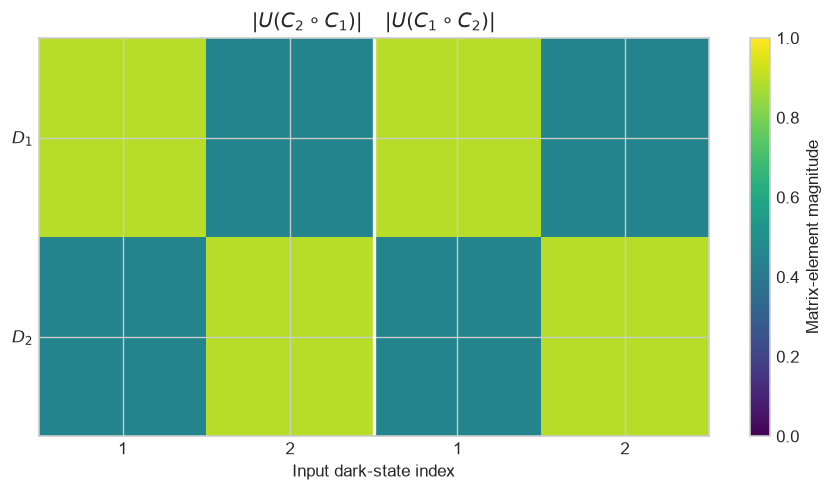

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
image = ax.imshow(np.hstack([np.abs(U_C2C1), np.abs(U_C1C2)]),
                  vmin=0, vmax=1, cmap='viridis', aspect='auto')
ax.axvline(1.5, color='white', lw=2)
ax.set(xticks=[0,1,2,3], xticklabels=['1','2','1','2'],
       yticks=[0,1], yticklabels=[r'$D_1$',r'$D_2$'],
       xlabel='Input dark-state index',
       title=r'$|U(C_2\circ C_1)|$    $|U(C_1\circ C_2)|$')
fig.colorbar(image, ax=ax, label='Matrix-element magnitude')
fig.tight_layout(); plt.show()


#### Reading the holonomy-magnitude plot

**How it was generated.** Both initial dark basis states are propagated through each loop order. Their final overlaps with $D_1$ and $D_2$ form the columns of the projected $2\times2$ evolution. A polar decomposition removes the small nonunitarity from leakage, and a common phase is removed to obtain an $SU(2)$ representative.

**Physical intuition.** The left and right $2\times2$ blocks have different transition magnitudes, showing that the two closed paths implement different logical rotations. The full complex matrices contain additional phase information captured by the nonzero commutator norm.

In [16]:
print('Final [P_D1, P_D2, leakage] after C2 o C1:', pops_C2C1)
print('Final [P_D1, P_D2, leakage] after C1 o C2:', pops_C1C2)
population_order_contrast = np.linalg.norm(pops_C2C1[:2] - pops_C1C2[:2])
print('Population order contrast:', population_order_contrast)
print('Non-Abelian commutator norm:', commutator_norm)
# assert population_order_contrast > 0.1


Final [P_D1, P_D2, leakage] after C2 o C1: [0.78206 0.21784 0.0001 ]
Final [P_D1, P_D2, leakage] after C1 o C2: [0.31493 0.68498 0.00009]
Population order contrast: 0.6606242283741653
Non-Abelian commutator norm: 0.7483217778582957


## 5. Representative RF and microwave controls

### Section overview

This section visualizes an illustrative RF dressing gate and three phase-coherent microwave envelopes. These traces communicate the intended control timing; they are not asserted to be the unique experimental pulses specified by the paper.

The RF dressing field is smoothly switched on before the microwave sequence and remains present during it. The three overlapping microwave pulses use QuaCCAToo's `gaussian_pulse`; setting `f_pulse=0` returns the envelope, while nonzero `phi_t` displays the phase-coherent in-phase quadrature. These shapes illustrate the control concept and are not claimed to be prescribed by the paper.

In [17]:
# Sample a common time axis for visualizing all applied controls.
t = np.linspace(0, t_end, 1400)
# Smoothly gate the RF dressing field on before and off after the MW sequence.
rf_env = 0.5*(np.tanh((t-rf_on)/edge_sigma)-np.tanh((t-rf_off)/edge_sigma))
# QuaCCAToo's Gaussian pulse function generates the three microwave envelopes.
mw_env = np.array([mw_Omega_MHz[j]*gaussian_pulse(t, t_mid=mw_centers[j], sigma=mw_sigma, f_pulse=0.0, phi_t=0.0) for j in range(3)])
mw_I = np.array([mw_Omega_MHz[j]*gaussian_pulse(t, t_mid=mw_centers[j], sigma=mw_sigma, f_pulse=0.0, phi_t=mw_phase_rad[j]) for j in range(3)])


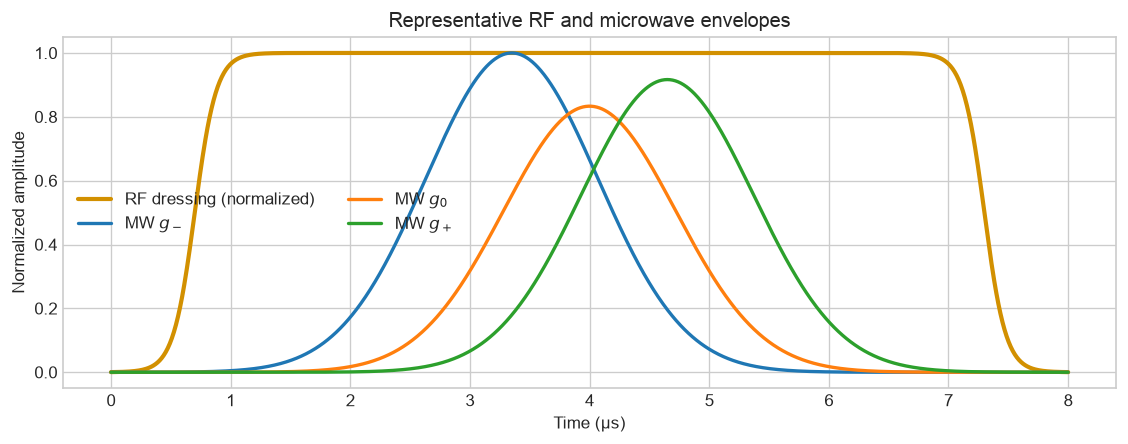

In [18]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.plot(t, rf_env, lw=2.5, color='#d29000', label='RF dressing (normalized)')
for j, label in enumerate([r'MW $g_-$', r'MW $g_0$', r'MW $g_+$']):
    ax.plot(t, mw_env[j]/mw_Omega_MHz.max(), lw=2, label=label)
ax.set(xlabel='Time (µs)', ylabel='Normalized amplitude',
       title='Representative RF and microwave envelopes')
ax.legend(ncol=2); fig.tight_layout(); plt.show()

#### Reading the RF/MW envelope plot

**How it was generated.** A smooth difference of hyperbolic tangents produces the normalized RF gate. QuaCCAToo's `gaussian_pulse` generates three microwave envelopes with editable centers, widths, and peak Rabi rates; the traces are normalized here only to compare timing.

**Physical intuition.** The RF field turns on first and remains present while the microwave controls act, so the ancilla is already dressed during the tripod operation. The overlapping microwave envelopes show that the three tripod legs can be controlled coherently rather than addressed as unrelated experiments.

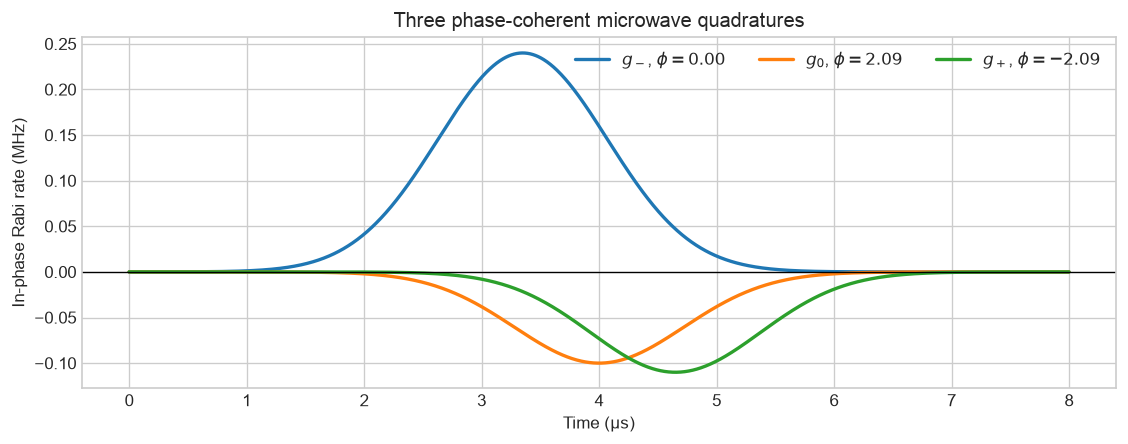

In [19]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))
for j, label in enumerate([r'$g_-$', r'$g_0$', r'$g_+$']):
    ax.plot(t, mw_I[j], lw=2, label=label+rf', $\phi={mw_phase_rad[j]:.2f}$')
ax.axhline(0, color='black', lw=0.8)
ax.set(xlabel='Time (µs)', ylabel='In-phase Rabi rate (MHz)',
       title='Three phase-coherent microwave quadratures')
ax.legend(ncol=3); fig.tight_layout(); plt.show()


#### Reading the microwave-quadrature plot

**How it was generated.** Each Gaussian envelope is multiplied by the cosine of its programmed carrier phase, displaying the in-phase component used by an IQ controller.

**Physical intuition.** Positive and negative traces do not represent negative power; they encode relative microwave phase. Those relative phases determine the complex tripod coefficients, the instantaneous bright/dark basis, and ultimately the non-Abelian holonomy.

## 6. Experimental calibration notes

### Section overview

The current notebook is an ideal coherent model. This checklist identifies the parameters that must be measured or added before interpreting the results as an experimental prediction.

- Change `B0_mT` to the measured axial field; QuaCCAToo then updates the full bare Hamiltonian and its RF/MW frequency metadata.
- Replace `rf_detuning_MHz`, `rf_Omega_MHz`, and `rf_phase_rad` with the actual two-tone rotating-frame parameters. These determine $c_j$ and the isolation gap $\Delta_{\rm RF}$.
- Verify $\Delta_{\rm RF}$ is large enough that the other dressed states remain off-resonant during the microwave operation.
- Replace the illustrative microwave amplitudes, phases, detunings, and envelopes with calibrated controls, including AC-Stark or Bloch–Siegert corrections if relevant.
- “Lowest” here means lowest rotating-frame quasienergy. Quasienergy ordering depends on frame conventions; the physical criterion is a selected, spectrally isolated dressed ancilla.

## 7. Complete RF/MW loop-order sequences in the nine-state model

### Sequence overview

This section reproduces the complete pulse sequence used in `NV_Rabi_Test.ipynb`, while retaining the RF detunings, RF couplings, MW amplitudes, and dressed-state coefficients defined earlier in this notebook. The two simulations use identical amplitude envelopes and differ only in whether $C_1$ or $C_2$ is performed first.

The tuple `("C1", "C2")` is chronological: $C_1$ is applied first and $C_2$ second, producing $U(C_2)U(C_1)$. The reversed tuple produces $U(C_1)U(C_2)$.

| Time interval | RF controls | Three MW controls | Phase operation |
|---|---|---|---|
| $0$–$4\,\mu\mathrm{s}$ | Smooth $\sin^2$ ramp on | Off | None |
| $4$–$6\,\mu\mathrm{s}$ | Fully on | Off | Dressed basis established |
| $6$–$12\,\mu\mathrm{s}$ | Fully on | Smooth $\sin^2$ ramp on | Initial effective phases fixed |
| $12$–$92\,\mu\mathrm{s}$ | Fully on | Fully on | First phase loop |
| $92$–$172\,\mu\mathrm{s}$ | Fully on | Fully on | Second phase loop |
| $172$–$178\,\mu\mathrm{s}$ | Fully on | Smooth $\cos^2$ ramp to zero | Both loops complete |
| $178$–$182\,\mu\mathrm{s}$ | Smooth $\cos^2$ ramp to zero | Zero | RF dressing removed |
| $t\ge182\,\mu\mathrm{s}$ | Zero | Zero | Final readout point |

The RF and MW fields stay continuously on during both phase loops. The MW fields are adiabatically removed first, followed by the RF fields. Event markers on every population figure identify the beginning and completion of each preparation, loop, and ramp-down stage.

### Modeling convention

QuaCCAToo `PulsedSim` evolves the complete nine-state NV–$^{14}$N Hilbert space in the resonant multi-rotating frame. The RF Hamiltonian from Section 2 is separated into static detunings and ramped off-diagonal RF couplings. Each MW leg couples one $m_s=0$ state to its corresponding bare $m_s=-1$ state. This retains the selected ancilla $|e\rangle$, the two higher dressed states $|e_0\rangle$ and $|e_+\rangle$, and all three $m_s=+1$ spectators without requiring a hundreds-of-microseconds GHz carrier-resolved integration.


In [20]:
# -----------------------------------------------------------------------------
# A. Use the same complete sequence timing as NV_Rabi_Test.ipynb
# -----------------------------------------------------------------------------
scheduled_rf_ramp_us = 4.0
scheduled_rf_settle_us = 2.0
scheduled_mw_ramp_us = 6.0
scheduled_loop_duration_us = 80.0
scheduled_reporting_step_us = 0.5

scheduled_t_rf_start_us = 0.0
scheduled_t_rf_on_us = scheduled_t_rf_start_us + scheduled_rf_ramp_us
scheduled_t_mw_start_us = scheduled_t_rf_on_us + scheduled_rf_settle_us
scheduled_t_loop_1_us = scheduled_t_mw_start_us + scheduled_mw_ramp_us
scheduled_t_loop_2_us = scheduled_t_loop_1_us + scheduled_loop_duration_us
scheduled_t_mw_down_us = scheduled_t_loop_2_us + scheduled_loop_duration_us
scheduled_t_mw_zero_us = scheduled_t_mw_down_us + scheduled_mw_ramp_us
scheduled_t_rf_down_us = scheduled_t_mw_zero_us
scheduled_t_rf_zero_us = scheduled_t_rf_down_us + scheduled_rf_ramp_us
scheduled_total_time_us = scheduled_t_rf_zero_us


def scheduled_sin2_ramp(time_us, start_us, duration_us):
    """Evaluate a smooth zero-to-one sin-squared ramp.

    Parameters
    ----------
    time_us : float or numpy.ndarray
        Physical time in microseconds.
    start_us : float
        Time at which the ramp begins.
    duration_us : float
        Positive ramp duration in microseconds.

    Returns
    -------
    float or numpy.ndarray
        Dimensionless fraction between zero and one with zero endpoint slopes.
    """
    coordinate = np.clip((np.asarray(time_us) - start_us) / duration_us, 0.0, 1.0)
    return np.sin(0.5 * np.pi * coordinate)**2


def scheduled_rf_envelope(time_us):
    """Return the common RF amplitude fraction over the complete sequence.

    Parameters
    ----------
    time_us : float or numpy.ndarray
        Physical sequence time in microseconds.

    Returns
    -------
    float or numpy.ndarray
        Smooth RF turn-on, unit plateau, and RF turn-off after MW removal.
    """
    time_array = np.asarray(time_us)
    ramp_up = scheduled_sin2_ramp(time_array, scheduled_t_rf_start_us, scheduled_rf_ramp_us)
    ramp_down = 1.0 - scheduled_sin2_ramp(
        time_array, scheduled_t_rf_down_us, scheduled_rf_ramp_us
    )
    result = np.where(
        time_array < scheduled_t_rf_on_us,
        ramp_up,
        np.where(
            time_array < scheduled_t_rf_down_us,
            1.0,
            np.where(time_array < scheduled_t_rf_zero_us, ramp_down, 0.0),
        ),
    )
    return float(result) if result.ndim == 0 else result


def scheduled_mw_envelope(time_us):
    """Return the common MW amplitude fraction over the complete sequence.

    Parameters
    ----------
    time_us : float or numpy.ndarray
        Physical sequence time in microseconds.

    Returns
    -------
    float or numpy.ndarray
        Zero before MW preparation, a smooth turn-on, unity through both loops,
        and a smooth turn-off while the RF dressing remains fully on.
    """
    time_array = np.asarray(time_us)
    ramp_up = scheduled_sin2_ramp(time_array, scheduled_t_mw_start_us, scheduled_mw_ramp_us)
    ramp_down = 1.0 - scheduled_sin2_ramp(
        time_array, scheduled_t_mw_down_us, scheduled_mw_ramp_us
    )
    result = np.where(
        time_array < scheduled_t_mw_start_us,
        0.0,
        np.where(
            time_array < scheduled_t_loop_1_us,
            ramp_up,
            np.where(
                time_array < scheduled_t_mw_down_us,
                1.0,
                np.where(time_array < scheduled_t_mw_zero_us, ramp_down, 0.0),
            ),
        ),
    )
    return float(result) if result.ndim == 0 else result


def scheduled_phase_winding(local_time_us, duration_us):
    """Evaluate the smooth 0-to-2pi phase winding from Equation (10).

    Parameters
    ----------
    local_time_us : float or numpy.ndarray
        Time measured from the beginning of the active loop.
    duration_us : float
        Loop duration in microseconds.

    Returns
    -------
    float or numpy.ndarray
        Phase in radians with zero derivative at both loop endpoints.
    """
    local_time_us = np.clip(np.asarray(local_time_us), 0.0, duration_us)
    return 2.0 * np.pi * np.sin(np.pi * local_time_us / (2.0 * duration_us))**2


scheduled_loop_leg = {"C1": 0, "C2": 2}


def scheduled_phase_vector(time_us, loop_order):
    """Return [phi_-, phi_0, phi_+] for the active chronological loop.

    Parameters
    ----------
    time_us : float
        Absolute sequence time in microseconds.
    loop_order : tuple of str
        Either ('C1','C2') or ('C2','C1').

    Returns
    -------
    numpy.ndarray, shape (3,)
        Additional effective MW phases in radians.
    """
    if tuple(loop_order) not in (("C1", "C2"), ("C2", "C1")):
        raise ValueError("loop_order must contain C1 and C2 exactly once")
    phases = np.zeros(3, dtype=float)
    if scheduled_t_loop_1_us <= time_us < scheduled_t_loop_2_us:
        active_loop = loop_order[0]
        phases[scheduled_loop_leg[active_loop]] = scheduled_phase_winding(
            time_us - scheduled_t_loop_1_us, scheduled_loop_duration_us
        )
    elif scheduled_t_loop_2_us <= time_us < scheduled_t_mw_down_us:
        active_loop = loop_order[1]
        phases[scheduled_loop_leg[active_loop]] = scheduled_phase_winding(
            time_us - scheduled_t_loop_2_us, scheduled_loop_duration_us
        )
    return phases


def scheduled_events(loop_order):
    """Return all event markers for one chronological loop ordering.

    Parameters
    ----------
    loop_order : tuple of str
        Chronological loop order.

    Returns
    -------
    list of tuple
        Entries (time_us, label, color) for RF/MW switching and loop starts.
    """
    return [
        (scheduled_t_rf_start_us, "RF ramp-up starts", "tab:orange"),
        (scheduled_t_rf_on_us, "RF on", "tab:orange"),
        (scheduled_t_mw_start_us, "MW ramp-up starts", "tab:blue"),
        (scheduled_t_loop_1_us, f"MW on / {loop_order[0]} starts", "tab:purple"),
        (scheduled_t_loop_2_us, f"{loop_order[1]} starts", "tab:pink"),
        (scheduled_t_mw_down_us, "MW ramp-down starts", "tab:blue"),
        (scheduled_t_mw_zero_us, "MW = 0 / RF ramp-down starts", "tab:orange"),
        (scheduled_t_rf_zero_us, "RF = 0", "black"),
    ]


def add_scheduled_event_markers(ax, loop_order, annotate=True):
    """Draw all pulse and loop event markers on a time-domain axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes that receives the vertical markers.
    loop_order : tuple of str
        Chronological loop order controlling the two loop labels.
    annotate : bool
        If True, add rotated labels at the top of the axes.

    Returns
    -------
    matplotlib.axes.Axes
        The supplied annotated axes.
    """
    for event_index, (event_time, label, color) in enumerate(scheduled_events(loop_order)):
        ax.axvline(event_time, color=color, ls=":", lw=1.0, alpha=0.75)
        if annotate:
            ax.text(
                event_time,
                0.98 - 0.08 * (event_index % 2),
                label,
                color=color,
                rotation=90,
                va="top",
                ha="right",
                fontsize=7.5,
                transform=ax.get_xaxis_transform(),
            )
    return ax


# -----------------------------------------------------------------------------
# B. Construct e, e0, e+ and embed the RF/MW controls in all nine NV states
# -----------------------------------------------------------------------------
scheduled_dressed_coefficients = np.asarray(evecs, dtype=complex).copy()
for dressed_index in range(3):
    coefficients = scheduled_dressed_coefficients[:, dressed_index]
    reference_coefficient = coefficients[np.argmax(np.abs(coefficients))]
    coefficients *= np.exp(-1j * np.angle(reference_coefficient))
    scheduled_dressed_coefficients[:, dressed_index] = coefficients / np.linalg.norm(coefficients)

scheduled_dressed_states = tuple(
    sum(
        coefficient * bare_state
        for coefficient, bare_state in zip(coefficients, states_m1)
    ).unit()
    for coefficients in scheduled_dressed_coefficients.T
)
scheduled_e_state, scheduled_e0_state, scheduled_eplus_state = scheduled_dressed_states

scheduled_P_gminus, scheduled_P_gzero, scheduled_P_gplus = [
    state * state.dag() for state in states_0
]
scheduled_P_e = scheduled_e_state * scheduled_e_state.dag()
scheduled_P_e0 = scheduled_e0_state * scheduled_e0_state.dag()
scheduled_P_eplus = scheduled_eplus_state * scheduled_eplus_state.dag()
scheduled_P_higher = scheduled_P_e0 + scheduled_P_eplus
scheduled_P_G = scheduled_P_gminus + scheduled_P_gzero + scheduled_P_gplus
scheduled_P_tripod = scheduled_P_G + scheduled_P_e
scheduled_P_all = qeye(nv.H0.dims[0])


def scheduled_embed_matrix(matrix, states, template_operator):
    """Embed a projected matrix in the complete nine-state Hilbert space.

    Parameters
    ----------
    matrix : numpy.ndarray, shape (N,N)
        Matrix in the ordered basis supplied by `states`.
    states : sequence of qutip.Qobj
        Full-space basis kets.
    template_operator : qutip.Qobj
        Operator carrying the desired full-space tensor dimensions.

    Returns
    -------
    qutip.Qobj
        Full-space operator with the requested projected matrix elements.
    """
    matrix = np.asarray(matrix, dtype=complex)
    if matrix.shape != (len(states), len(states)):
        raise ValueError("matrix and state-basis dimensions do not match")
    result = 0.0 * template_operator
    for row, bra_state in enumerate(states):
        for column, ket_state in enumerate(states):
            result += matrix[row, column] * bra_state * ket_state.dag()
    return result


scheduled_rf_detuning_matrix = np.diag(rf_detuning_MHz.astype(complex))
scheduled_rf_coupling_matrix = H_rf_array - scheduled_rf_detuning_matrix

# Shift the rotating frame so the selected lowest branch has zero quasienergy
# at full RF amplitude. Detunings remain static while the RF couplings are ramped.
scheduled_H_static = scheduled_embed_matrix(
    scheduled_rf_detuning_matrix - evals[0] * np.eye(3),
    states_m1,
    nv.H0,
)
scheduled_H_rf_control = scheduled_embed_matrix(
    scheduled_rf_coupling_matrix,
    states_m1,
    nv.H0,
)

# Program base phases that compensate the complex RF coefficients, making the
# initial projected tripod couplings real and positive before either loop winds.
scheduled_mw_base_phases = -np.angle(scheduled_dressed_coefficients[:, 0])
scheduled_mw_bare_amplitudes = np.asarray(mw_Omega_MHz, dtype=float)
scheduled_bare_complex_couplings = (
    scheduled_mw_bare_amplitudes * np.exp(-1j * scheduled_mw_base_phases)
)
scheduled_projected_couplings = (
    np.conjugate(scheduled_dressed_coefficients[:, 0])
    * scheduled_bare_complex_couplings
)
assert np.max(np.abs(np.angle(scheduled_projected_couplings))) < 1e-10
assert np.allclose(np.abs(scheduled_projected_couplings), Omega_paper, atol=1e-12)

scheduled_mw_operators = []
for ground_state, bare_excited_state, amplitude_mhz in zip(
    states_0,
    states_m1,
    scheduled_mw_bare_amplitudes,
):
    transition = bare_excited_state * ground_state.dag()
    x_operator = transition + transition.dag()
    y_operator = -1j * transition + 1j * transition.dag()
    scheduled_mw_operators.extend([
        0.5 * amplitude_mhz * x_operator,
        0.5 * amplitude_mhz * y_operator,
    ])

scheduled_control_operators = [scheduled_H_rf_control] + scheduled_mw_operators


def scheduled_control_shapes(loop_order):
    """Build the RF envelope and six MW IQ functions for one loop order.

    Parameters
    ----------
    loop_order : tuple of str
        Chronological loop order.

    Returns
    -------
    list of callable
        Seven QuaCCAToo pulse shapes ordered RF, then
        [X_-,Y_-,X_0,Y_0,X_+,Y_+].
    """
    def rf_shape(solver_time, **_):
        return scheduled_rf_envelope(solver_time / (2.0 * np.pi))

    shapes = [rf_shape]
    for leg in range(3):
        for quadrature in ("x", "y"):
            def mw_shape(solver_time, leg=leg, quadrature=quadrature, **_):
                physical_time_us = solver_time / (2.0 * np.pi)
                phase = (
                    scheduled_mw_base_phases[leg]
                    + scheduled_phase_vector(physical_time_us, loop_order)[leg]
                )
                iq_weight = np.cos(phase) if quadrature == "x" else np.sin(phase)
                return scheduled_mw_envelope(physical_time_us) * iq_weight
            shapes.append(mw_shape)
    return shapes


# Use the same order-sensitive logical input as Section 4, lifted into the
# physical nine-state ground manifold with compensated zero starting phases.
scheduled_Om, scheduled_O0, scheduled_Op = np.abs(scheduled_projected_couplings)
scheduled_Ominus0 = np.sqrt(scheduled_Om**2 + scheduled_O0**2)
scheduled_Ototal = np.linalg.norm(scheduled_projected_couplings)
scheduled_D1 = (
    scheduled_O0 * states_0[0] - scheduled_Om * states_0[1]
) / scheduled_Ominus0
scheduled_D2 = (
    scheduled_Op * (scheduled_Om * states_0[0] + scheduled_O0 * states_0[1])
    - scheduled_Ominus0**2 * states_0[2]
) / (scheduled_Ototal * scheduled_Ominus0)
scheduled_initial_state = (scheduled_D1 + scheduled_D2).unit()

scheduled_dressed_overlap = np.array([
    [state_a.overlap(state_b) for state_b in scheduled_dressed_states]
    for state_a in scheduled_dressed_states
])
assert np.allclose(scheduled_dressed_overlap, np.eye(3), atol=1e-12)

print("Complete sequence duration (us):", scheduled_total_time_us)
print("Dressed branch detunings at full RF (MHz):", evals - evals[0])
print("Compensated projected MW couplings (MHz):", scheduled_projected_couplings)
print("Initial state norm:", scheduled_initial_state.overlap(scheduled_initial_state))


Complete sequence duration (us): 182.0
Dressed branch detunings at full RF (MHz): [0.      0.63168 1.07177]
Compensated projected MW couplings (MHz): [0.11217+0.j 0.15451-0.j 0.09455-0.j]
Initial state norm: (0.9999999999999998+0j)


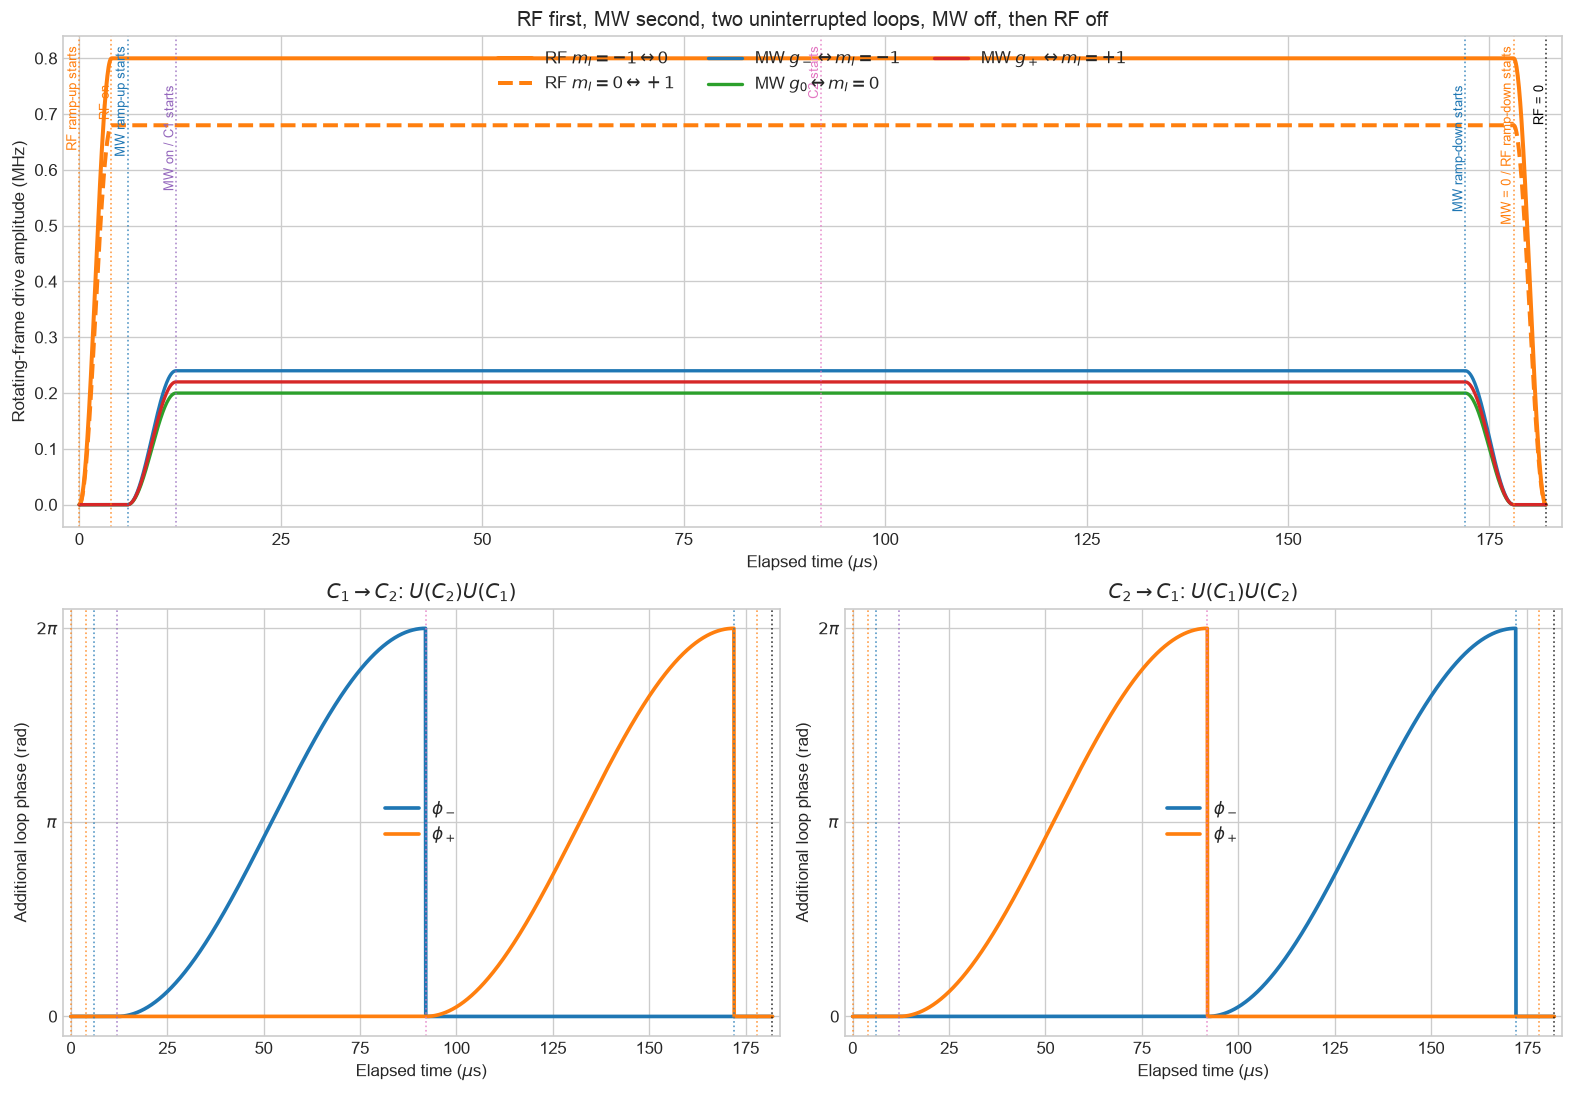

In [21]:
# -----------------------------------------------------------------------------
# C. Plot the RF/MW envelopes and both chronological phase orders
# -----------------------------------------------------------------------------
scheduled_control_times_us = np.linspace(0.0, scheduled_total_time_us, 2401)
scheduled_rf_envelopes_mhz = np.array([
    rate * scheduled_rf_envelope(scheduled_control_times_us)
    for rate in rf_Omega_MHz
])
scheduled_mw_envelopes_mhz = np.array([
    amplitude * scheduled_mw_envelope(scheduled_control_times_us)
    for amplitude in scheduled_mw_bare_amplitudes
])

fig = plt.figure(figsize=(13, 9), constrained_layout=True)
grid = fig.add_gridspec(2, 2, height_ratios=(1.15, 1.0))
ax_envelopes = fig.add_subplot(grid[0, :])
ax_phase_forward = fig.add_subplot(grid[1, 0])
ax_phase_reverse = fig.add_subplot(grid[1, 1], sharey=ax_phase_forward)

for envelope, label, style in zip(
    scheduled_rf_envelopes_mhz,
    (r"RF $m_I=-1\leftrightarrow0$", r"RF $m_I=0\leftrightarrow+1$"),
    ("-", "--"),
):
    ax_envelopes.plot(
        scheduled_control_times_us,
        envelope,
        lw=2.4,
        ls=style,
        color="tab:orange",
        label=label,
    )

for envelope, label, color in zip(
    scheduled_mw_envelopes_mhz,
    (r"MW $g_-\leftrightarrow m_I=-1$", r"MW $g_0\leftrightarrow m_I=0$", r"MW $g_+\leftrightarrow m_I=+1$"),
    ("tab:blue", "tab:green", "tab:red"),
):
    ax_envelopes.plot(scheduled_control_times_us, envelope, lw=2.0, color=color, label=label)

add_scheduled_event_markers(ax_envelopes, ("C1", "C2"), annotate=True)
ax_envelopes.set(
    xlim=(-2.0, scheduled_total_time_us + 2.0),
    xlabel=r"Elapsed time ($\mu$s)",
    ylabel="Rotating-frame drive amplitude (MHz)",
    title="RF first, MW second, two uninterrupted loops, MW off, then RF off",
)
ax_envelopes.legend(ncol=3, loc="upper center")

for ax, loop_order, title in (
    (ax_phase_forward, ("C1", "C2"), r"$C_1\rightarrow C_2$: $U(C_2)U(C_1)$"),
    (ax_phase_reverse, ("C2", "C1"), r"$C_2\rightarrow C_1$: $U(C_1)U(C_2)$"),
):
    phases = np.array([
        scheduled_phase_vector(time_us, loop_order)
        for time_us in scheduled_control_times_us
    ])
    ax.plot(scheduled_control_times_us, phases[:, 0], lw=2.2, label=r"$\phi_-$")
    ax.plot(scheduled_control_times_us, phases[:, 2], lw=2.2, label=r"$\phi_+$")
    add_scheduled_event_markers(ax, loop_order, annotate=False)
    ax.set(
        xlim=(-2.0, scheduled_total_time_us + 2.0),
        xlabel=r"Elapsed time ($\mu$s)",
        ylabel="Additional loop phase (rad)",
        yticks=[0.0, np.pi, 2.0 * np.pi],
        yticklabels=["0", r"$\pi$", r"$2\pi$"],
        title=title,
    )
    ax.legend()

plt.show()


#### Reading the complete pulse and phase schedule

**How the plot was generated.** The upper panel uses the same $182\,\mu\mathrm{s}$ schedule as `NV_Rabi_Test.ipynb`, now displaying both RF transition envelopes and all three MW envelopes from this notebook's editable amplitudes. The lower panels show Equation (10) applied to $\phi_-$ and $\phi_+$ in the two chronological orders.

**Physical intuition.** The RF dressing is fully established before the MW tripod is opened. Both drive families remain uninterrupted during the two loops. The only distinction between the left and right phase panels is which non-commuting loop occurs first. The MW fields then close smoothly while the RF remains on, after which the RF dressing is removed for drive-free readout.


In [22]:
# -----------------------------------------------------------------------------
# D. Propagate both complete chronological sequences with QuaCCAToo PulsedSim
# -----------------------------------------------------------------------------
scheduled_observables = [
    scheduled_P_gminus,
    scheduled_P_gzero,
    scheduled_P_gplus,
    scheduled_P_e,
    scheduled_P_higher,
    scheduled_P_G,
    scheduled_P_tripod,
    scheduled_P_all,
]
scheduled_population_labels = (
    r"$P_{g_-}$",
    r"$P_{g_0}$",
    r"$P_{g_+}$",
    r"$P_e$",
    r"$P_{e_0}+P_{e_+}$",
    r"$P_G$",
    r"$P_{g_-}+P_{g_0}+P_{g_+}+P_e$",
    r"$P_{\rm all}$",
)


def run_scheduled_loop_order(loop_order, reporting_step_us=0.5):
    """Run RF-on, MW-on, two loops, MW-off, and RF-off with PulsedSim.

    Parameters
    ----------
    loop_order : tuple of str
        Chronological pair ('C1','C2') or ('C2','C1').
    reporting_step_us : float
        Positive population-reporting interval in microseconds.

    Returns
    -------
    dict
        Loop order, reporting times, (N,8) requested populations, and the final
        nine-state ket after both RF and MW controls reach zero.
    """
    if reporting_step_us <= 0.0:
        raise ValueError("reporting_step_us must be positive")

    system = QSys(
        H0=scheduled_H_static,
        rho0=scheduled_initial_state,
        observable=None,
        units_H0="MHz",
    )
    experiment = PulsedSim(system)
    shapes = scheduled_control_shapes(loop_order)
    number_of_intervals = int(np.ceil(scheduled_total_time_us / reporting_step_us))
    times_us = np.linspace(0.0, scheduled_total_time_us, number_of_intervals + 1)
    populations = np.empty((len(times_us), len(scheduled_observables)), dtype=float)
    populations[0] = [
        float(np.real(expect(observable, experiment.rho)))
        for observable in scheduled_observables
    ]

    for time_index in range(1, len(times_us)):
        duration_us = float(times_us[time_index] - times_us[time_index - 1])
        experiment.add_pulse(
            duration=duration_us,
            h1=scheduled_control_operators,
            pulse_shape=shapes,
            pulse_params={},
            time_steps=4,
            options={"nsteps": 100000, "atol": 1e-10, "rtol": 1e-9},
        )
        populations[time_index] = [
            float(np.real(expect(observable, experiment.rho)))
            for observable in scheduled_observables
        ]

    assert np.allclose(populations[:, 7], 1.0, atol=1e-7)
    return {
        "order": tuple(loop_order),
        "times_us": times_us,
        "populations": populations,
        "final_state": experiment.rho.copy(),
    }


scheduled_result_C2C1 = run_scheduled_loop_order(
    ("C1", "C2"),
    scheduled_reporting_step_us,
)
scheduled_result_C1C2 = run_scheduled_loop_order(
    ("C2", "C1"),
    scheduled_reporting_step_us,
)

for result in (scheduled_result_C2C1, scheduled_result_C1C2):
    populations = result["populations"]
    print("Chronological loop order:", result["order"])
    print("  maximum normalization error:", np.max(np.abs(populations[:, 7] - 1.0)))
    print("  maximum selected-ancilla population:", np.max(populations[:, 3]))
    print("  maximum higher-dressed population:", np.max(populations[:, 4]))
    print("  final requested populations:", populations[-1])


Chronological loop order: ('C1', 'C2')
  maximum normalization error: 6.661338147750939e-16
  maximum selected-ancilla population: 0.004027073058508068
  maximum higher-dressed population: 0.029837746712015018
  final requested populations: [0.64357 0.10696 0.24895 0.00033 0.0002  0.99948 0.9998  1.     ]
Chronological loop order: ('C2', 'C1')
  maximum normalization error: 6.661338147750939e-16
  maximum selected-ancilla population: 0.0038426565914301144
  maximum higher-dressed population: 0.03055987145281149
  final requested populations: [0.3618  0.00379 0.63411 0.00019 0.00011 0.9997  0.99989 1.     ]


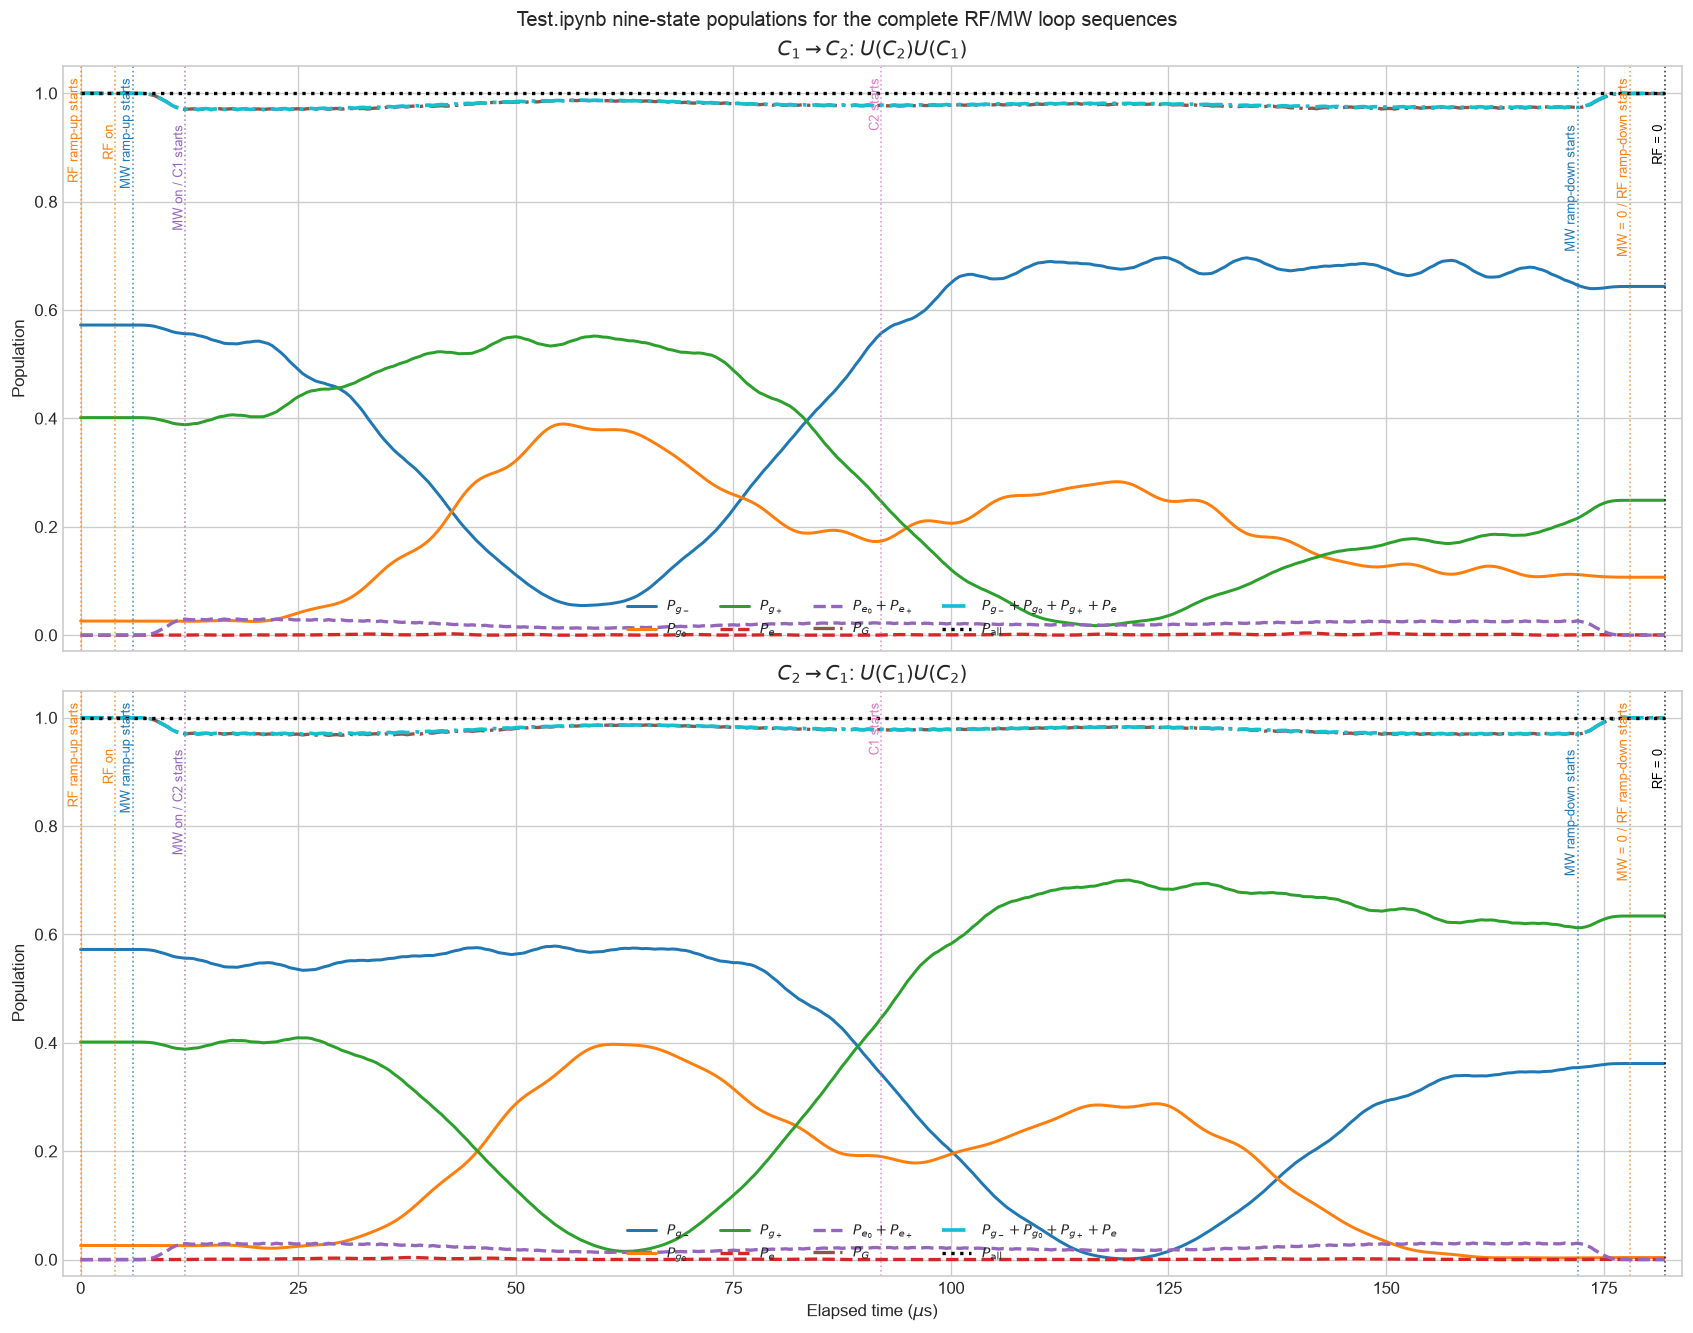

Final C1 -> C2 populations: [0.64357 0.10696 0.24895 0.00033 0.0002  0.99948 0.9998  1.     ]
Final C2 -> C1 populations: [0.3618  0.00379 0.63411 0.00019 0.00011 0.9997  0.99989 1.     ]
Final ground-state population-order contrast: 0.488248226181987


In [23]:
# -----------------------------------------------------------------------------
# E. Plot all requested populations with every pulse and loop event marker
# -----------------------------------------------------------------------------
scheduled_population_colors = (
    "tab:blue", "tab:orange", "tab:green", "tab:red",
    "tab:purple", "tab:brown", "tab:cyan", "black",
)
scheduled_population_styles = ("-", "-", "-", "--", "--", "-.", "-.", ":")
scheduled_population_widths = (1.8, 1.8, 1.8, 2.0, 2.0, 2.0, 2.2, 2.0)

fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True, sharey=True, constrained_layout=True)
for ax, result, title in (
    (axes[0], scheduled_result_C2C1, r"$C_1\rightarrow C_2$: $U(C_2)U(C_1)$"),
    (axes[1], scheduled_result_C1C2, r"$C_2\rightarrow C_1$: $U(C_1)U(C_2)$"),
):
    for column, (label, color, style, width) in enumerate(zip(
        scheduled_population_labels,
        scheduled_population_colors,
        scheduled_population_styles,
        scheduled_population_widths,
    )):
        ax.plot(
            result["times_us"],
            result["populations"][:, column],
            color=color,
            ls=style,
            lw=width,
            label=label,
        )
    add_scheduled_event_markers(ax, result["order"], annotate=True)
    ax.set(
        xlim=(-2.0, scheduled_total_time_us + 2.0),
        ylim=(-0.03, 1.05),
        ylabel="Population",
        title=title,
    )
    ax.legend(ncol=4, fontsize=8.5, loc="lower center")

axes[1].set_xlabel(r"Elapsed time ($\mu$s)")
fig.suptitle("Test.ipynb nine-state populations for the complete RF/MW loop sequences")
plt.show()

scheduled_final_C2C1 = scheduled_result_C2C1["populations"][-1]
scheduled_final_C1C2 = scheduled_result_C1C2["populations"][-1]
scheduled_ground_order_contrast = np.linalg.norm(
    scheduled_final_C2C1[:3] - scheduled_final_C1C2[:3]
)
print("Final C1 -> C2 populations:", scheduled_final_C2C1)
print("Final C2 -> C1 populations:", scheduled_final_C1C2)
print("Final ground-state population-order contrast:", scheduled_ground_order_contrast)


#### Reading the complete-sequence population plots

**How the plots were generated.** Each QuaCCAToo `PulsedSim` object carries the same nine-state initial ket through $0.5\,\mu\mathrm{s}$ reporting intervals without projective measurement. The figures display $P_{g_-}$, $P_{g_0}$, $P_{g_+}$, $P_e$, combined higher-dressed population, $P_G$, total tripod population, and the full nine-state trace. Vertical markers show RF and MW preparation, both loop starts, both ramp-down stages, and the separate MW-zero and RF-zero times.

**Final comparison.** The $C_1\rightarrow C_2$ sequence ends with ground populations approximately $[0.644,0.107,0.249]$, $P_e=3.3\times10^{-4}$, and final higher-dressed population $2.0\times10^{-4}$. Reversing the loops gives ground populations $[0.362,0.0038,0.634]$, $P_e=1.9\times10^{-4}$, and final higher-dressed population $1.1\times10^{-4}$. The resulting ground-population order contrast is $0.488$.

**Physical intuition.** RF preparation alone leaves the initial $m_s=0$ state unchanged. Turning on the MW tripod establishes the dark/bright structure. The phase windings then move the dark basis and redistribute ground-state population. The final ground-state distributions differ because reversing the loops reverses the order of two non-commuting geometric operations. The final ramp stages leave both controls at zero for direct comparison and readout.


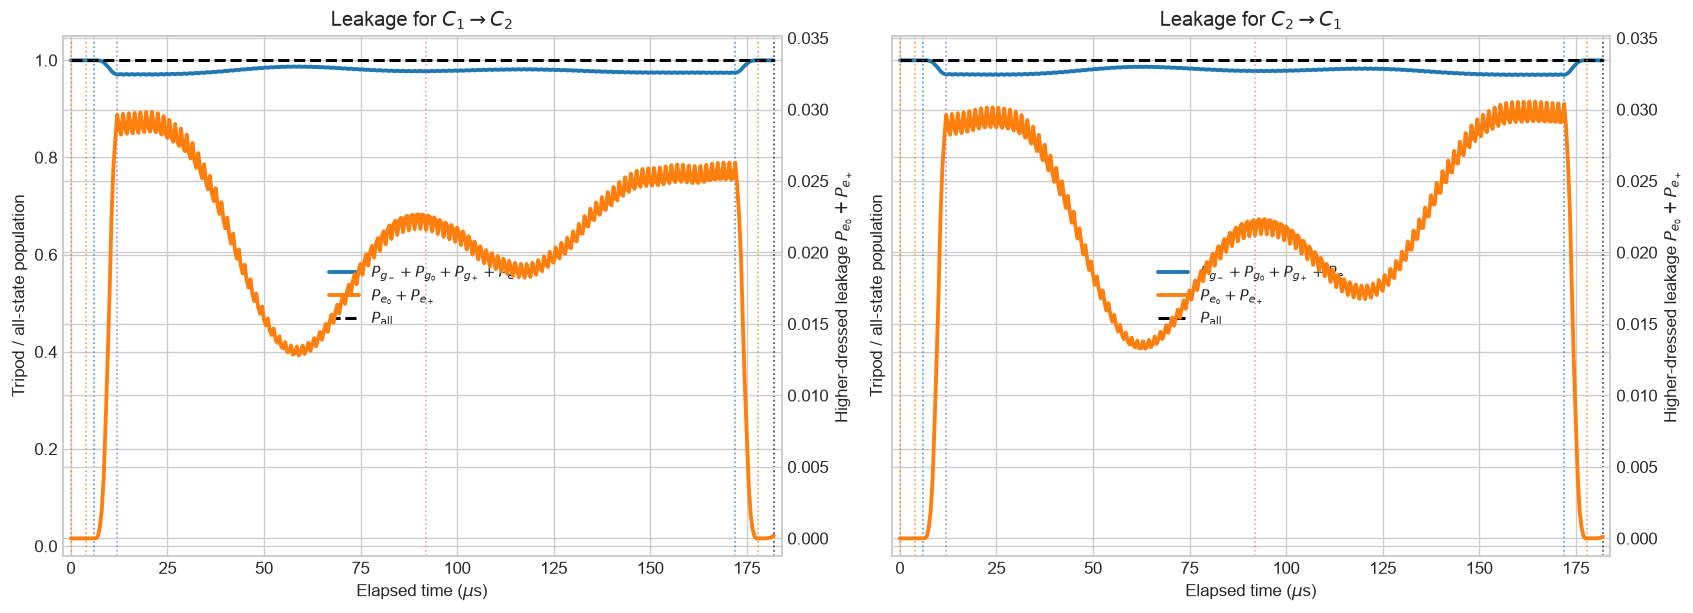

('C1', 'C2') max higher-dressed leakage = 0.029837746712015018 ; max spectator population = 2.5673907444456745e-16
('C2', 'C1') max higher-dressed leakage = 0.03055987145281149 ; max spectator population = 2.42861286636753e-16


In [24]:
# -----------------------------------------------------------------------------
# F. Plot tripod retention and the magnified e0/e+ leakage for both orders
# -----------------------------------------------------------------------------
scheduled_maximum_higher = max(
    np.max(scheduled_result_C2C1["populations"][:, 4]),
    np.max(scheduled_result_C1C2["populations"][:, 4]),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True, constrained_layout=True)
for ax, result, title in (
    (axes[0], scheduled_result_C2C1, r"Leakage for $C_1\rightarrow C_2$"),
    (axes[1], scheduled_result_C1C2, r"Leakage for $C_2\rightarrow C_1$"),
):
    times_us = result["times_us"]
    populations = result["populations"]
    tripod_line = ax.plot(
        times_us,
        populations[:, 6],
        lw=2.3,
        color="tab:blue",
        label=r"$P_{g_-}+P_{g_0}+P_{g_+}+P_e$",
    )[0]
    all_line = ax.plot(
        times_us,
        populations[:, 7],
        lw=1.8,
        ls="--",
        color="black",
        label=r"$P_{\rm all}$",
    )[0]

    leakage_axis = ax.twinx()
    leakage_line = leakage_axis.plot(
        times_us,
        populations[:, 4],
        lw=2.3,
        color="tab:orange",
        label=r"$P_{e_0}+P_{e_+}$",
    )[0]

    add_scheduled_event_markers(ax, result["order"], annotate=False)
    ax.set(
        xlim=(-2.0, scheduled_total_time_us + 2.0),
        ylim=(-0.02, 1.05),
        xlabel=r"Elapsed time ($\mu$s)",
        ylabel="Tripod / all-state population",
        title=title,
    )
    leakage_axis.set(
        ylim=(-0.04 * scheduled_maximum_higher, 1.15 * scheduled_maximum_higher),
        ylabel=r"Higher-dressed leakage $P_{e_0}+P_{e_+}$",
    )
    ax.legend(
        [tripod_line, leakage_line, all_line],
        [line.get_label() for line in (tripod_line, leakage_line, all_line)],
        fontsize=9,
        loc="center",
    )

plt.show()

for result in (scheduled_result_C2C1, scheduled_result_C1C2):
    populations = result["populations"]
    scheduled_spectator_population = populations[:, 7] - populations[:, 6] - populations[:, 4]
    print(
        result["order"],
        "max higher-dressed leakage =",
        np.max(populations[:, 4]),
        "; max spectator population =",
        np.max(np.abs(scheduled_spectator_population)),
    )


#### Reading the complete-sequence leakage plots

**How the plots were generated.** The left axis shows the intended four-state tripod population and the full nine-state normalization. The orange $P_{e_0}+P_{e_+}$ trace uses a dedicated right-hand population axis so leakage remains visible even when it is much smaller than one. All pulse and loop events remain marked by vertical lines.

**Numerical result.** The maximum combined higher-dressed population is $2.98\times10^{-2}$ for $C_1\rightarrow C_2$ and $3.06\times10^{-2}$ for $C_2\rightarrow C_1$. The $m_s=+1$ spectator population remains below $2.6\times10^{-16}$. This leakage is larger than in `NV_Rabi_Test.ipynb` because the MW amplitudes used here are stronger relative to the smaller RF isolation gap, although most of the transient leakage returns before the controls reach zero.

**Physical intuition.** Each MW leg addresses a bare $m_s=-1$ nuclear state, which is a superposition of all three RF-dressed eigenstates. The selected ancilla is resonant, while $|e_0\rangle$ and $|e_+\rangle$ are separated by the RF quasienergy gaps and are therefore imperfectly but not infinitely suppressed. The smooth drive ramps and slow phase loops reduce this unwanted transfer. A difference between $P_{\rm all}$ and the sum of the tripod and higher-dressed curves would indicate population in the retained $m_s=+1$ spectators.
